# 📋 Fichas por Categoría de Edad — HID Covered (m) / min (GLMM Hurdle M2)

**Notebook complementario a `04_glmm_HID.ipynb`**

Este notebook presenta **fichas visuales independientes** para cada grupo de edad,
basadas en las **Medias Marginales Estimadas (EMMs)** del modelo GLMM bayesiano
M2 (Hurdle Gamma, logit + Gamma/log, efectos aleatorios por jugador en ambas partes).

El modelo **Hurdle Gamma** descompone la respuesta en **dos procesos generadores**:

1. **Parte ψ (psi, logit)**: P(HID > 0) — probabilidad de que el jugador alcance velocidades > 4 m/s durante la fase
2. **Parte μ (mu, Gamma/log)**: E[HID/min | HID > 0] — distancia acumulada a alta intensidad cuando sí ocurre
3. **Combinada**: E[Y] = P(HID > 0) × E[HID/min | HID > 0]

Cada ficha muestra tres paneles:

| Panel | Contenido |
|-------|-----------|  
| **Izquierdo** | EMMs combinadas E[Y] por nivel de cada VI de diseño (con HDI 95 %) |
| **Derecho** | Impacto absoluto (Δ) de cada VI, ordenado por magnitud |
| **Inferior** | 4 escenarios combinados de diseño de tarea |

**Modelo de referencia**: M2, seleccionado por LOO-CV como mejor modelo predictivo
(peso stacking = 0.915, elpd_diff = 0). Incluye los 4 efectos principales de diseño
+ GrupoEdad, sin interacciones.

**Implicación clave**: Al igual que en Golpeos/min, el modelo M2 es **aditivo** — los
efectos de las VI de diseño son constantes (en escala log/logit) entre categorías de edad.
Las fichas muestran perfiles cualitativamente idénticos entre grupos; las diferencias
absolutas reflejan únicamente el nivel base de cada categoría.

> 🔑 Los modelos M1 y M2 se **ajustan directamente** en este notebook a partir
> de los datos fuente. No hay datos hardcodeados: los EMMs se calculan
> dinámicamente a partir de la posterior bayesiana.

> ⚠️ **Nota sobre el Hurdle**: A diferencia de un modelo Gamma simple (Toques/min),
> el Hurdle Gamma tiene un enlace **logit** en la parte binaria. Esto implica que
> los **efectos relativos combinados NO son exactamente idénticos** entre categorías
> de edad, incluso sin interacciones. Los OR y los exp(β) de la parte mu SÍ son
> constantes, pero la combinación ψ×μ a través de la función expit genera
> pequeñas variaciones dependientes del nivel base de cada grupo.

In [7]:
# ══════════════════════════════════════════════════════════════════════════
#  CELDA 1 — Imports y carga de datos
# ══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import bambi as bmb
import arviz as az
import pymc as pm
from scipy.special import expit

az.style.use("arviz-darkgrid")
%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 140,
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

# ── Carga de datos ───────────────────────────────────────────────────────
df = pd.read_excel("../Datos/Matriz_V3.xlsx")

rename_map = {
    "Total Touches / min":                         "ToquesMin",
    "Golpeos +15 m/s / min":                       "GolpeosMin",
    "Distance Covered (m) / min":                  "DistanciaMin",
    "High Intensity Distance (20 km/h) / min":     "HIDMin",    # ← VARIABLE OBJETIVO
    "Player Id":                                   "PlayerId",
    "Phase Id":                                    "PhaseId",
}
df = df.rename(columns=rename_map)
vd = "HIDMin"

for col in ["Espacio", "Agrupacion", "Polaridad", "Equilibrio",
            "GrupoEdad", "PlayerId"]:
    df[col] = df[col].astype("category")

print(f"✅ Datos cargados: {df.shape[0]} obs × {df.shape[1]} columnas")
print(f"   Jugadores únicos: {df['PlayerId'].nunique()}")
print(f"   Categorías de edad: {sorted(df['GrupoEdad'].cat.categories.tolist())}")
print(f"   % ceros en {vd}: {(df[vd] == 0).mean()*100:.1f} %")

✅ Datos cargados: 4446 obs × 19 columnas
   Jugadores únicos: 253
   Categorías de edad: ['Cadete', 'Infantil', 'Juvenil', 'Neskak', 'Senior Masculino']
   % ceros en HIDMin: 30.1 %


In [8]:
# ══════════════════════════════════════════════════════════════════════════
#  CELDA 2 — Ajuste de modelos M1 y M2  (Hurdle Gamma, ≈ 20–40 min)
# ══════════════════════════════════════════════════════════════════════════

draws, tune, chains, cores, seed = 2000, 1000, 4, 1, 42

# ── M1: Efectos principales de las 4 VI de diseño (ambas partes) ─────────
print("⏳ Ajustando M1 (efectos principales, Hurdle Gamma)...")
formula_m1 = bmb.Formula(
    "HIDMin ~ Espacio + Agrupacion + Polaridad + Equilibrio + (1|PlayerId)",
    "psi ~ Espacio + Agrupacion + Polaridad + Equilibrio + (1|PlayerId)"
)
m1 = bmb.Model(formula_m1, df, family="hurdle_gamma")
res1 = m1.fit(draws=draws, tune=tune, chains=chains, cores=cores, random_seed=seed)
print("✅ M1 ajustado")

# ── M2: + GrupoEdad (ambas partes) — MODELO FINAL según LOO-CV ──────────
print("⏳ Ajustando M2 (+ GrupoEdad, Hurdle Gamma)...")
formula_m2 = bmb.Formula(
    "HIDMin ~ Espacio + Agrupacion + Polaridad + Equilibrio + GrupoEdad + (1|PlayerId)",
    "psi ~ Espacio + Agrupacion + Polaridad + Equilibrio + GrupoEdad + (1|PlayerId)"
)
m2 = bmb.Model(formula_m2, df, family="hurdle_gamma")
res2 = m2.fit(draws=draws, tune=tune, chains=chains, cores=cores, random_seed=seed)
print("✅ M2 ajustado")

# Modelo de referencia para fichas (M2 seleccionado por LOO-CV, peso = 0.915)
res_final = res2

# ── Verificación rápida de convergencia ──────────────────────────────────
rhat_m1 = az.rhat(res1)
rhat_m2 = az.rhat(res2)
print(f"\nR-hat máximo M1: {max(rhat_m1.max().values()):.4f}")
print(f"R-hat máximo M2: {max(rhat_m2.max().values()):.4f}")

⏳ Ajustando M1 (efectos principales, Hurdle Gamma)...


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [alpha, Intercept, Espacio, Agrupacion, Polaridad, Equilibrio, 1|PlayerId_sigma, 1|PlayerId_offset, psi_Intercept, psi_Espacio, psi_Agrupacion, psi_Polaridad, psi_Equilibrio, psi_1|PlayerId_sigma, psi_1|PlayerId_offset]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 98 seconds.


✅ M1 ajustado
⏳ Ajustando M2 (+ GrupoEdad, Hurdle Gamma)...


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [alpha, Intercept, Espacio, Agrupacion, Polaridad, Equilibrio, GrupoEdad, 1|PlayerId_sigma, 1|PlayerId_offset, psi_Intercept, psi_Espacio, psi_Agrupacion, psi_Polaridad, psi_Equilibrio, psi_GrupoEdad, psi_1|PlayerId_sigma, psi_1|PlayerId_offset]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 119 seconds.


✅ M2 ajustado

R-hat máximo M1: 1.0028
R-hat máximo M2: 1.0030


In [9]:
# ══════════════════════════════════════════════════════════════════════════
#  CELDA 3 — Extracción de posteriors, cálculo de EMMs y función ficha
#  Modelo de referencia: M2 (aditivo, sin interacciones)
# ══════════════════════════════════════════════════════════════════════════
from itertools import product

# ── Niveles de cada VI ───────────────────────────────────────────────────
niveles_vi = {
    "Espacio":     ["amplio", "reducido"],
    "Agrupacion":  ["grande", "pequeño"],
    "Polaridad":   ["NoPolarizado", "Polarizado"],
    "Equilibrio":  ["Desequilibrio", "Equilibrio"],
}

# Referencia Bambi = 1ª categoría alfabética
ref_vi = {k: sorted(v)[0] for k, v in niveles_vi.items()}

# ── Niveles de GrupoEdad (detección dinámica) ───────────────────────────
# Parte mu
_ge_dim_mu = [d for d in res2.posterior["GrupoEdad"].dims if d not in ("chain", "draw")][0]
_ge_post_mu = [str(lv) for lv in res2.posterior["GrupoEdad"].coords[_ge_dim_mu].values]
# Parte psi
_ge_dim_psi = [d for d in res2.posterior["psi_GrupoEdad"].dims if d not in ("chain", "draw")][0]
_ge_post_psi = [str(lv) for lv in res2.posterior["psi_GrupoEdad"].coords[_ge_dim_psi].values]

_ge_all  = sorted(df["GrupoEdad"].cat.categories)
_ge_ref  = [lv for lv in _ge_all if lv not in _ge_post_mu]
niveles_ge = sorted(_ge_ref + _ge_post_mu)

# ── Muestras posteriores M2 ─────────────────────────────────────────────
post2 = res2.posterior
n_samples = post2.dims["chain"] * post2.dims["draw"]

# Parte mu
intercept_mu = post2["Intercept"].values.flatten()
betas_mu = {}
for vi in niveles_vi:
    arr = post2[vi].values
    betas_mu[vi] = arr[:, :, 0].flatten() if arr.ndim == 3 else arr.flatten()

# Parte psi
intercept_psi = post2["psi_Intercept"].values.flatten()
betas_psi = {}
for vi in niveles_vi:
    arr = post2[f"psi_{vi}"].values
    betas_psi[vi] = arr[:, :, 0].flatten() if arr.ndim == 3 else arr.flatten()

# GrupoEdad — parte mu
betas_ge_mu = {}
for i, lev in enumerate(_ge_post_mu):
    betas_ge_mu[lev] = post2["GrupoEdad"].values[:, :, i].flatten()
for ref_lev in _ge_ref:
    betas_ge_mu[ref_lev] = np.zeros(n_samples)

# GrupoEdad — parte psi
betas_ge_psi = {}
for i, lev in enumerate(_ge_post_psi):
    betas_ge_psi[lev] = post2["psi_GrupoEdad"].values[:, :, i].flatten()
for ref_lev in _ge_ref:
    betas_ge_psi[ref_lev] = np.zeros(n_samples)

print(f"Muestras posteriores: {n_samples}")
print(f"GrupoEdad — ref: {_ge_ref}, no-ref (mu): {_ge_post_mu}")
print(f"niveles_ge: {niveles_ge}")


# ── Función EMM para Hurdle Gamma ────────────────────────────────────────
def calcular_emm_hurdle(target_levels, betas_mu, intercept_mu,
                        betas_psi, intercept_psi, all_niveles,
                        betas_ge_mu=None, betas_ge_psi=None, ge_level=None):
    """
    EMM posterior para un modelo Hurdle Gamma (M2, aditivo).
    Retorna 3 arrays de n_samples:
      - emm_psi:      P(HID > 0) en escala de probabilidad
      - emm_mu:       E[HID/min | HID > 0] en escala natural
      - emm_combined: E[Y] = psi × mu
    """
    marg = {k: v for k, v in all_niveles.items() if k not in target_levels}
    if marg:
        marg_combos = list(product(*marg.values()))
        marg_keys = list(marg.keys())
    else:
        marg_combos = [()]
        marg_keys = []
    ref = {k: sorted(v)[0] for k, v in all_niveles.items()}
    n = len(intercept_mu)
    sum_psi = np.zeros(n)
    sum_mu = np.zeros(n)
    sum_combined = np.zeros(n)
    for combo in marg_combos:
        # Parte mu: log(E[Y|Y>0])
        log_mu = intercept_mu.copy()
        for factor, level in target_levels.items():
            if level != ref[factor]:
                log_mu += betas_mu[factor]
        for factor, level in zip(marg_keys, combo):
            if level != ref[factor]:
                log_mu += betas_mu[factor]
        if betas_ge_mu is not None and ge_level is not None:
            log_mu += betas_ge_mu[ge_level]
        # Parte psi: logit(P(Y>0))
        logit_psi = intercept_psi.copy()
        for factor, level in target_levels.items():
            if level != ref[factor]:
                logit_psi += betas_psi[factor]
        for factor, level in zip(marg_keys, combo):
            if level != ref[factor]:
                logit_psi += betas_psi[factor]
        if betas_ge_psi is not None and ge_level is not None:
            logit_psi += betas_ge_psi[ge_level]
        mu_nat = np.exp(log_mu)
        psi_prob = expit(logit_psi)
        sum_mu += mu_nat
        sum_psi += psi_prob
        sum_combined += psi_prob * mu_nat
    nc = len(marg_combos)
    return sum_psi / nc, sum_mu / nc, sum_combined / nc


def emm_tabla(samples):
    """Retorna (media, hdi_lo, hdi_hi)."""
    return np.mean(samples), *az.hdi(samples, hdi_prob=0.95)


# ══════════════════════════════════════════════════════════════════════════
#  CÁLCULO AUTOMÁTICO DE emm_global y emm_vi_ge
#  Nota: se almacenan 3 niveles (psi, mu, combined) por cada EMM
# ══════════════════════════════════════════════════════════════════════════

etiquetas_vi = {
    "Espacio": "Espacio", "Agrupacion": "Agrupación",
    "Polaridad": "Polaridad", "Equilibrio": "Equilibrio",
}

# ── EMM global por GrupoEdad ────────────────────────────────────────────
emm_global = {}  # ge → {psi: (m,lo,hi), mu: (m,lo,hi), combined: (m,lo,hi)}
for ge in niveles_ge:
    s_psi, s_mu, s_comb = calcular_emm_hurdle(
        {}, betas_mu, intercept_mu, betas_psi, intercept_psi,
        niveles_vi, betas_ge_mu=betas_ge_mu, betas_ge_psi=betas_ge_psi,
        ge_level=ge
    )
    emm_global[ge] = {
        "psi": emm_tabla(s_psi),
        "mu": emm_tabla(s_mu),
        "combined": emm_tabla(s_comb),
    }

print("\n── EMM global por GrupoEdad ──")
for ge in niveles_ge:
    mp, lop, hip = emm_global[ge]["psi"]
    mm, lom, him = emm_global[ge]["mu"]
    print(f"  {ge:20s}  P(HID>0)={mp:.3f} [{lop:.3f}, {hip:.3f}]  "
          f"E[HID/min|HID>0]={mm:.4f} [{lom:.4f}, {him:.4f}]")

# ── EMMs por VI × GrupoEdad ─────────────────────────────────────────────
emm_vi_ge = {}  # cat → vi_label → nivel → {psi:(m,lo,hi), mu:..., combined:...}
for cat in niveles_ge:
    emm_vi_ge[cat] = {}
    for vi in niveles_vi:
        emm_vi_ge[cat][etiquetas_vi[vi]] = {}
        for nivel in niveles_vi[vi]:
            s_psi, s_mu, s_comb = calcular_emm_hurdle(
                {vi: nivel}, betas_mu, intercept_mu,
                betas_psi, intercept_psi, niveles_vi,
                betas_ge_mu=betas_ge_mu, betas_ge_psi=betas_ge_psi,
                ge_level=cat
            )
            emm_vi_ge[cat][etiquetas_vi[vi]][nivel] = {
                "psi": emm_tabla(s_psi),
                "mu": emm_tabla(s_mu),
                "combined": emm_tabla(s_comb),
            }

print("\n✅ emm_global y emm_vi_ge calculados dinámicamente a partir de la posterior")


# ══════════════════════════════════════════════════════════════════════════
#  CONSTANTES DE VISUALIZACIÓN Y FUNCIONES
# ══════════════════════════════════════════════════════════════════════════

nivel_boost = {
    "Polaridad": "Polarizado",   "Espacio": "amplio",
    "Agrupación": "pequeño",     "Equilibrio": "Desequilibrio",
}
nivel_reduce = {
    "Polaridad": "NoPolarizado", "Espacio": "reducido",
    "Agrupación": "grande",      "Equilibrio": "Equilibrio",
}
etiquetas_nivel = {
    "NoPolarizado": "No Polarizado", "Polarizado": "Polarizado",
    "reducido": "Reducido",          "amplio": "Amplio",
    "pequeño": "Pequeño (≤4v≤4)",    "grande": "Grande (≥5v≥5)",
    "Desequilibrio": "Desequilibrio","Equilibrio": "Equilibrio",
}
orden_vi = ["Polaridad", "Espacio", "Agrupación", "Equilibrio"]

# Paleta amplia
_paleta_base = ["#1B9E77", "#D95F02", "#7570B3", "#E7298A", "#66A61E",
                "#E6AB02", "#A6761D", "#666666"]
colores_cat = {cat: _paleta_base[i % len(_paleta_base)]
               for i, cat in enumerate(sorted(niveles_ge))}
COLOR_BOOST  = "#2C7BB6"
COLOR_REDUCE = "#FDAE61"
COLOR_NS     = "#BDBDBD"
ESC_COLORES  = ["#4575B4", "#91BFDB", "#FC8D59", "#D73027"]

# Ordenar categorías por P(HID>0) descendente (métrica más intuitiva)
orden_categorias = sorted(niveles_ge,
                          key=lambda x: emm_global[x]["psi"][0], reverse=True)


def calcular_escenarios(cat):
    """Devuelve 4 escenarios con P(HID>0) y E[HID/min|HID>0] por separado."""
    vi = emm_vi_ge[cat]
    gp = emm_global[cat]["psi"][0]
    gm = emm_global[cat]["mu"][0]

    # Ratios por parte separada
    r_b_psi = {v: vi[v][nivel_boost[v]]["psi"][0]  / gp for v in orden_vi}
    r_r_psi = {v: vi[v][nivel_reduce[v]]["psi"][0] / gp for v in orden_vi}
    r_b_mu  = {v: vi[v][nivel_boost[v]]["mu"][0]   / gm for v in orden_vi}
    r_r_mu  = {v: vi[v][nivel_reduce[v]]["mu"][0]  / gm for v in orden_vi}

    escenarios = [
        ("Máximo estímulo",
         gp * r_b_psi["Polaridad"] * r_b_psi["Espacio"] * r_b_psi["Agrupación"] * r_b_psi["Equilibrio"],
         gm * r_b_mu["Polaridad"]  * r_b_mu["Espacio"]  * r_b_mu["Agrupación"]  * r_b_mu["Equilibrio"],
         "Pol · Amp · Peq · Deseq"),
        ("Favorable (top-2 VI)",
         gp * r_b_psi["Polaridad"] * r_b_psi["Espacio"] * r_r_psi["Agrupación"] * r_r_psi["Equilibrio"],
         gm * r_b_mu["Polaridad"]  * r_b_mu["Espacio"]  * r_r_mu["Agrupación"]  * r_r_mu["Equilibrio"],
         "Pol · Amp · Gra · Equil"),
        ("Desfavorable (top-2 ×)",
         gp * r_r_psi["Polaridad"] * r_r_psi["Espacio"] * r_b_psi["Agrupación"] * r_b_psi["Equilibrio"],
         gm * r_r_mu["Polaridad"]  * r_r_mu["Espacio"]  * r_b_mu["Agrupación"]  * r_b_mu["Equilibrio"],
         "NoPol · Red · Peq · Deseq"),
        ("Mínimo estímulo",
         gp * r_r_psi["Polaridad"] * r_r_psi["Espacio"] * r_r_psi["Agrupación"] * r_r_psi["Equilibrio"],
         gm * r_r_mu["Polaridad"]  * r_r_mu["Espacio"]  * r_r_mu["Agrupación"]  * r_r_mu["Equilibrio"],
         "NoPol · Red · Gra · Equil"),
    ]
    return escenarios  # [(nombre, psi, mu, desc), ...]


def _barras_vi(ax, vi_data, metrica, global_val, color_cat, xlabel, titulo):
    """Panel reutilizable: barras horizontales de EMM por nivel de cada VI."""
    y = 0
    yticks, ytick_labels = [], []
    vi_label_positions = []
    for vi in reversed(orden_vi):
        for is_boost, nk in [(False, nivel_reduce[vi]),
                             (True,  nivel_boost[vi])]:
            emm = vi_data[vi][nk][metrica][0]
            lo  = vi_data[vi][nk][metrica][1]
            hi  = vi_data[vi][nk][metrica][2]
            c = COLOR_NS if vi == "Equilibrio" else (COLOR_BOOST if is_boost else COLOR_REDUCE)
            ax.barh(y, emm, height=0.62, color=c, alpha=0.85,
                    edgecolor="white", linewidth=0.5)
            ax.errorbar(emm, y, xerr=[[emm - lo], [hi - emm]],
                        fmt="none", ecolor="#333", elinewidth=1, capsize=3)
            # Formato de anotación según métrica
            if metrica == "psi":
                ax.text(emm + (global_val * 0.02), y, f"{emm:.3f}",
                        va="center", fontsize=8.5, fontweight="bold")
            else:
                ax.text(emm + (global_val * 0.02), y, f"{emm:.4f}",
                        va="center", fontsize=8.5, fontweight="bold")
            yticks.append(y)
            ytick_labels.append(etiquetas_nivel[nk])
            y += 1
        vi_label_positions.append(((y - 1.5), vi))
        y += 1.2

    ax.axvline(global_val, color=color_cat, lw=1.8, ls="--", alpha=0.7, zorder=0,
               label=f"Media = {global_val:.4f}" if metrica != "psi" else f"Media = {global_val:.3f}")
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels, fontsize=9)
    for yc, vi_name in vi_label_positions:
        ax.annotate(vi_name, xy=(-0.02, yc), xycoords=("axes fraction", "data"),
                    fontsize=10.5, fontweight="bold", ha="right", va="center",
                    color="#444444")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_title(titulo, fontsize=13, fontweight="bold", pad=12)
    ax.legend(fontsize=8, loc="lower right", framealpha=0.8)
    ax.set_xlim(left=0)
    ax.grid(axis="x", alpha=0.25, ls=":")
    ax.spines[["top", "right"]].set_visible(False)


def _impacto_vi(ax, vi_data, metrica, color_cat, xlabel, titulo, fmt_abs, fmt_pct):
    """Panel reutilizable: barras de impacto absoluto Δ y % por VI."""
    deltas, pcts, d_colors, vi_labels = [], [], [], []
    for vi in orden_vi:
        emm_b = vi_data[vi][nivel_boost[vi]][metrica][0]
        emm_r = vi_data[vi][nivel_reduce[vi]][metrica][0]
        deltas.append(emm_b - emm_r)
        pcts.append((emm_b / emm_r - 1) * 100 if emm_r > 0 else 0)
        d_colors.append(COLOR_NS if vi == "Equilibrio" else COLOR_BOOST)
        vi_labels.append(vi)
    y_d = np.arange(len(orden_vi))
    ax.barh(y_d, deltas, height=0.55, color=d_colors, alpha=0.85,
            edgecolor="white", linewidth=0.5)
    for i, (d, p) in enumerate(zip(deltas, pcts)):
        txt_c = "#333" if orden_vi[i] != "Equilibrio" else "#999"
        sign = "+" if d >= 0 else ""
        ax.text(max(d, 0) + max(abs(v) for v in deltas) * 0.04, i,
                f"{sign}{d:{fmt_abs}}  ({p:+.1f} %)",
                va="center", fontsize=10, fontweight="bold", color=txt_c)
        if orden_vi[i] == "Equilibrio":
            ax.text(max(d, 0) + max(abs(v) for v in deltas) * 0.04, i - 0.30,
                    "(n.s.)", fontsize=8, color="#999", fontstyle="italic")
    ax.set_yticks(y_d)
    ax.set_yticklabels(vi_labels, fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_title(titulo, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlim(left=min(0, min(deltas) * 1.1),
                right=max(deltas) * 1.8 if max(deltas) > 0 else 0.1)
    ax.grid(axis="x", alpha=0.25, ls=":")
    ax.spines[["top", "right"]].set_visible(False)


def generar_ficha(categoria):
    """
    Genera ficha de 3 filas para una categoría de edad:
      Fila 1: EMMs por nivel de VI  (P(HID>0) izq, E[HID/min|HID>0] der)
      Fila 2: Impacto Δ absoluto + % por VI (P(HID>0) izq, E[HID/min|HID>0] der)
      Fila 3: 4 escenarios combinados con ambas métricas
    """
    vi_data     = emm_vi_ge[categoria]
    glob        = emm_global[categoria]
    escenarios  = calcular_escenarios(categoria)
    color       = colores_cat[categoria]
    g_psi       = glob["psi"][0]
    g_mu        = glob["mu"][0]

    fig = plt.figure(figsize=(18, 20), facecolor="white")
    fig.suptitle(f"📋  Ficha HID — {categoria}\n"
                 f"P(sprint) global = {g_psi:.3f}  |  "
                 f"E[HID/min|HID>0] global = {g_mu:.4f} m/min",
                 fontsize=17, fontweight="bold", y=0.99, color=color)

    gs = gridspec.GridSpec(3, 2, height_ratios=[3, 1.8, 1.8],
                           hspace=0.38, wspace=0.35,
                           left=0.10, right=0.96, top=0.93, bottom=0.04)

    # ── FILA 1: EMMs por nivel de cada VI ────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    _barras_vi(ax1, vi_data, "psi", g_psi, color,
               xlabel="P(HID > 0)",
               titulo="Probabilidad de Sprint\nP(HID > 0)")

    ax2 = fig.add_subplot(gs[0, 1])
    _barras_vi(ax2, vi_data, "mu", g_mu, color,
               xlabel="E[HID/min | HID > 0]",
               titulo="Intensidad Condicional\nE[HID/min | HID > 0]")

    # ── FILA 2: Impacto absoluto Δ y % por VI ───────────────────────────
    ax_d1 = fig.add_subplot(gs[1, 0])
    _impacto_vi(ax_d1, vi_data, "psi", color,
                xlabel="Δ P(HID > 0)",
                titulo="Impacto Absoluto — P(HID > 0)\n(nivel ↑HID − nivel ↓HID)",
                fmt_abs=".3f", fmt_pct=".1f")

    ax_d2 = fig.add_subplot(gs[1, 1])
    _impacto_vi(ax_d2, vi_data, "mu", color,
                xlabel="Δ E[HID/min | HID > 0]",
                titulo="Impacto Absoluto — E[HID/min | HID > 0]\n(nivel ↑HID − nivel ↓HID)",
                fmt_abs=".4f", fmt_pct=".1f")

    # ── FILA 3: Escenarios con ambas métricas ───────────────────────────
    ax3 = fig.add_subplot(gs[2, :])
    esc_nombres = [e[0] for e in escenarios]
    esc_psi     = [e[1] for e in escenarios]
    esc_mu      = [e[2] for e in escenarios]
    esc_desc    = [e[3] for e in escenarios]
    y_e = np.arange(len(escenarios))

    bar_h = 0.35
    ax3.barh(y_e - bar_h/2, esc_psi, height=bar_h,
             color="#E76F51", alpha=0.85, edgecolor="white",
             linewidth=0.5, label="P(HID > 0)")
    ax3.barh(y_e + bar_h/2, esc_mu, height=bar_h,
             color="#264653", alpha=0.85, edgecolor="white",
             linewidth=0.5, label="E[HID/min|HID>0] (m/min)")

    for i in range(len(escenarios)):
        ax3.text(esc_psi[i] + 0.008, y_e[i] - bar_h/2,
                 f" P = {esc_psi[i]:.3f}", va="center",
                 fontsize=10, fontweight="bold", color="#E76F51")
        ax3.text(esc_mu[i] + 0.008, y_e[i] + bar_h/2,
                 f" μ = {esc_mu[i]:.4f}", va="center",
                 fontsize=10, fontweight="bold", color="#264653")

    ax3.set_yticks(y_e)
    ax3.set_yticklabels([f"{n}\n({d})" for n, d in zip(esc_nombres, esc_desc)],
                         fontsize=9, fontweight="bold")
    ax3.set_xlabel("Valor EMM", fontsize=11)
    ax3.set_title("Escenarios Combinados — P(sprint) y E[HID/min|HID>0]",
                  fontsize=13, fontweight="bold", pad=12)
    ax3.legend(fontsize=9, loc="lower right", framealpha=0.8)
    xmax = max(max(esc_psi), max(esc_mu)) * 1.3
    ax3.set_xlim(left=0, right=xmax if xmax > 0 else 1)
    ax3.grid(axis="x", alpha=0.25, ls=":")
    ax3.spines[["top", "right"]].set_visible(False)
    ax3.invert_yaxis()

    plt.show()
    return fig


print("\n✅ Funciones de visualización listas")
print(f"   Categorías (↓P(HID>0)): {orden_categorias}")
print(f"   Escenarios de ejemplo ({orden_categorias[-1]}):")
for n, p, m, d in calcular_escenarios(orden_categorias[-1]):
    print(f"     {n:28s}  →  P(HID>0)={p:.3f}  E[HID/min|HID>0]={m:.4f} m/min  ({d})")

Muestras posteriores: 8000
GrupoEdad — ref: ['Cadete'], no-ref (mu): ['Infantil', 'Juvenil', 'Neskak', 'Senior Masculino']
niveles_ge: ['Cadete', 'Infantil', 'Juvenil', 'Neskak', 'Senior Masculino']

── EMM global por GrupoEdad ──
  Cadete                P(HID>0)=0.652 [0.567, 0.734]  E[HID/min|HID>0]=1.6099 [1.3412, 1.8822]
  Infantil              P(HID>0)=0.457 [0.361, 0.548]  E[HID/min|HID>0]=1.2765 [1.0456, 1.5171]
  Juvenil               P(HID>0)=0.880 [0.840, 0.921]  E[HID/min|HID>0]=2.8367 [2.4599, 3.2550]
  Neskak                P(HID>0)=0.487 [0.409, 0.571]  E[HID/min|HID>0]=1.2255 [1.0522, 1.4065]
  Senior Masculino      P(HID>0)=0.876 [0.835, 0.913]  E[HID/min|HID>0]=3.6110 [3.1301, 4.0773]

✅ emm_global y emm_vi_ge calculados dinámicamente a partir de la posterior

✅ Funciones de visualización listas
   Categorías (↓P(HID>0)): ['Juvenil', 'Senior Masculino', 'Cadete', 'Neskak', 'Infantil']
   Escenarios de ejemplo (Infantil):
     Máximo estímulo               →  P(HID>0)=0

---
## Fichas individuales por categoría de edad

Se genera automáticamente una ficha por cada nivel de `GrupoEdad` detectado
en los datos, ordenadas de mayor a menor P(HID > 0) global.

Cada ficha muestra:
- **Izquierda**: P(HID > 0) — probabilidad de que el jugador alcance velocidades de alta intensidad (> 4 m/s)
- **Derecha**: E[HID/min | HID > 0] — distancia media a alta intensidad condicional cuando ocurre sprint


════════════════════════════════════════════════════════════════════════════════
  1 · Juvenil
      P(HID>0) = 0.880 [0.840, 0.921]
      E[HID/min|HID>0] = 2.8367 [2.4599, 3.2550] m/min
════════════════════════════════════════════════════════════════════════════════


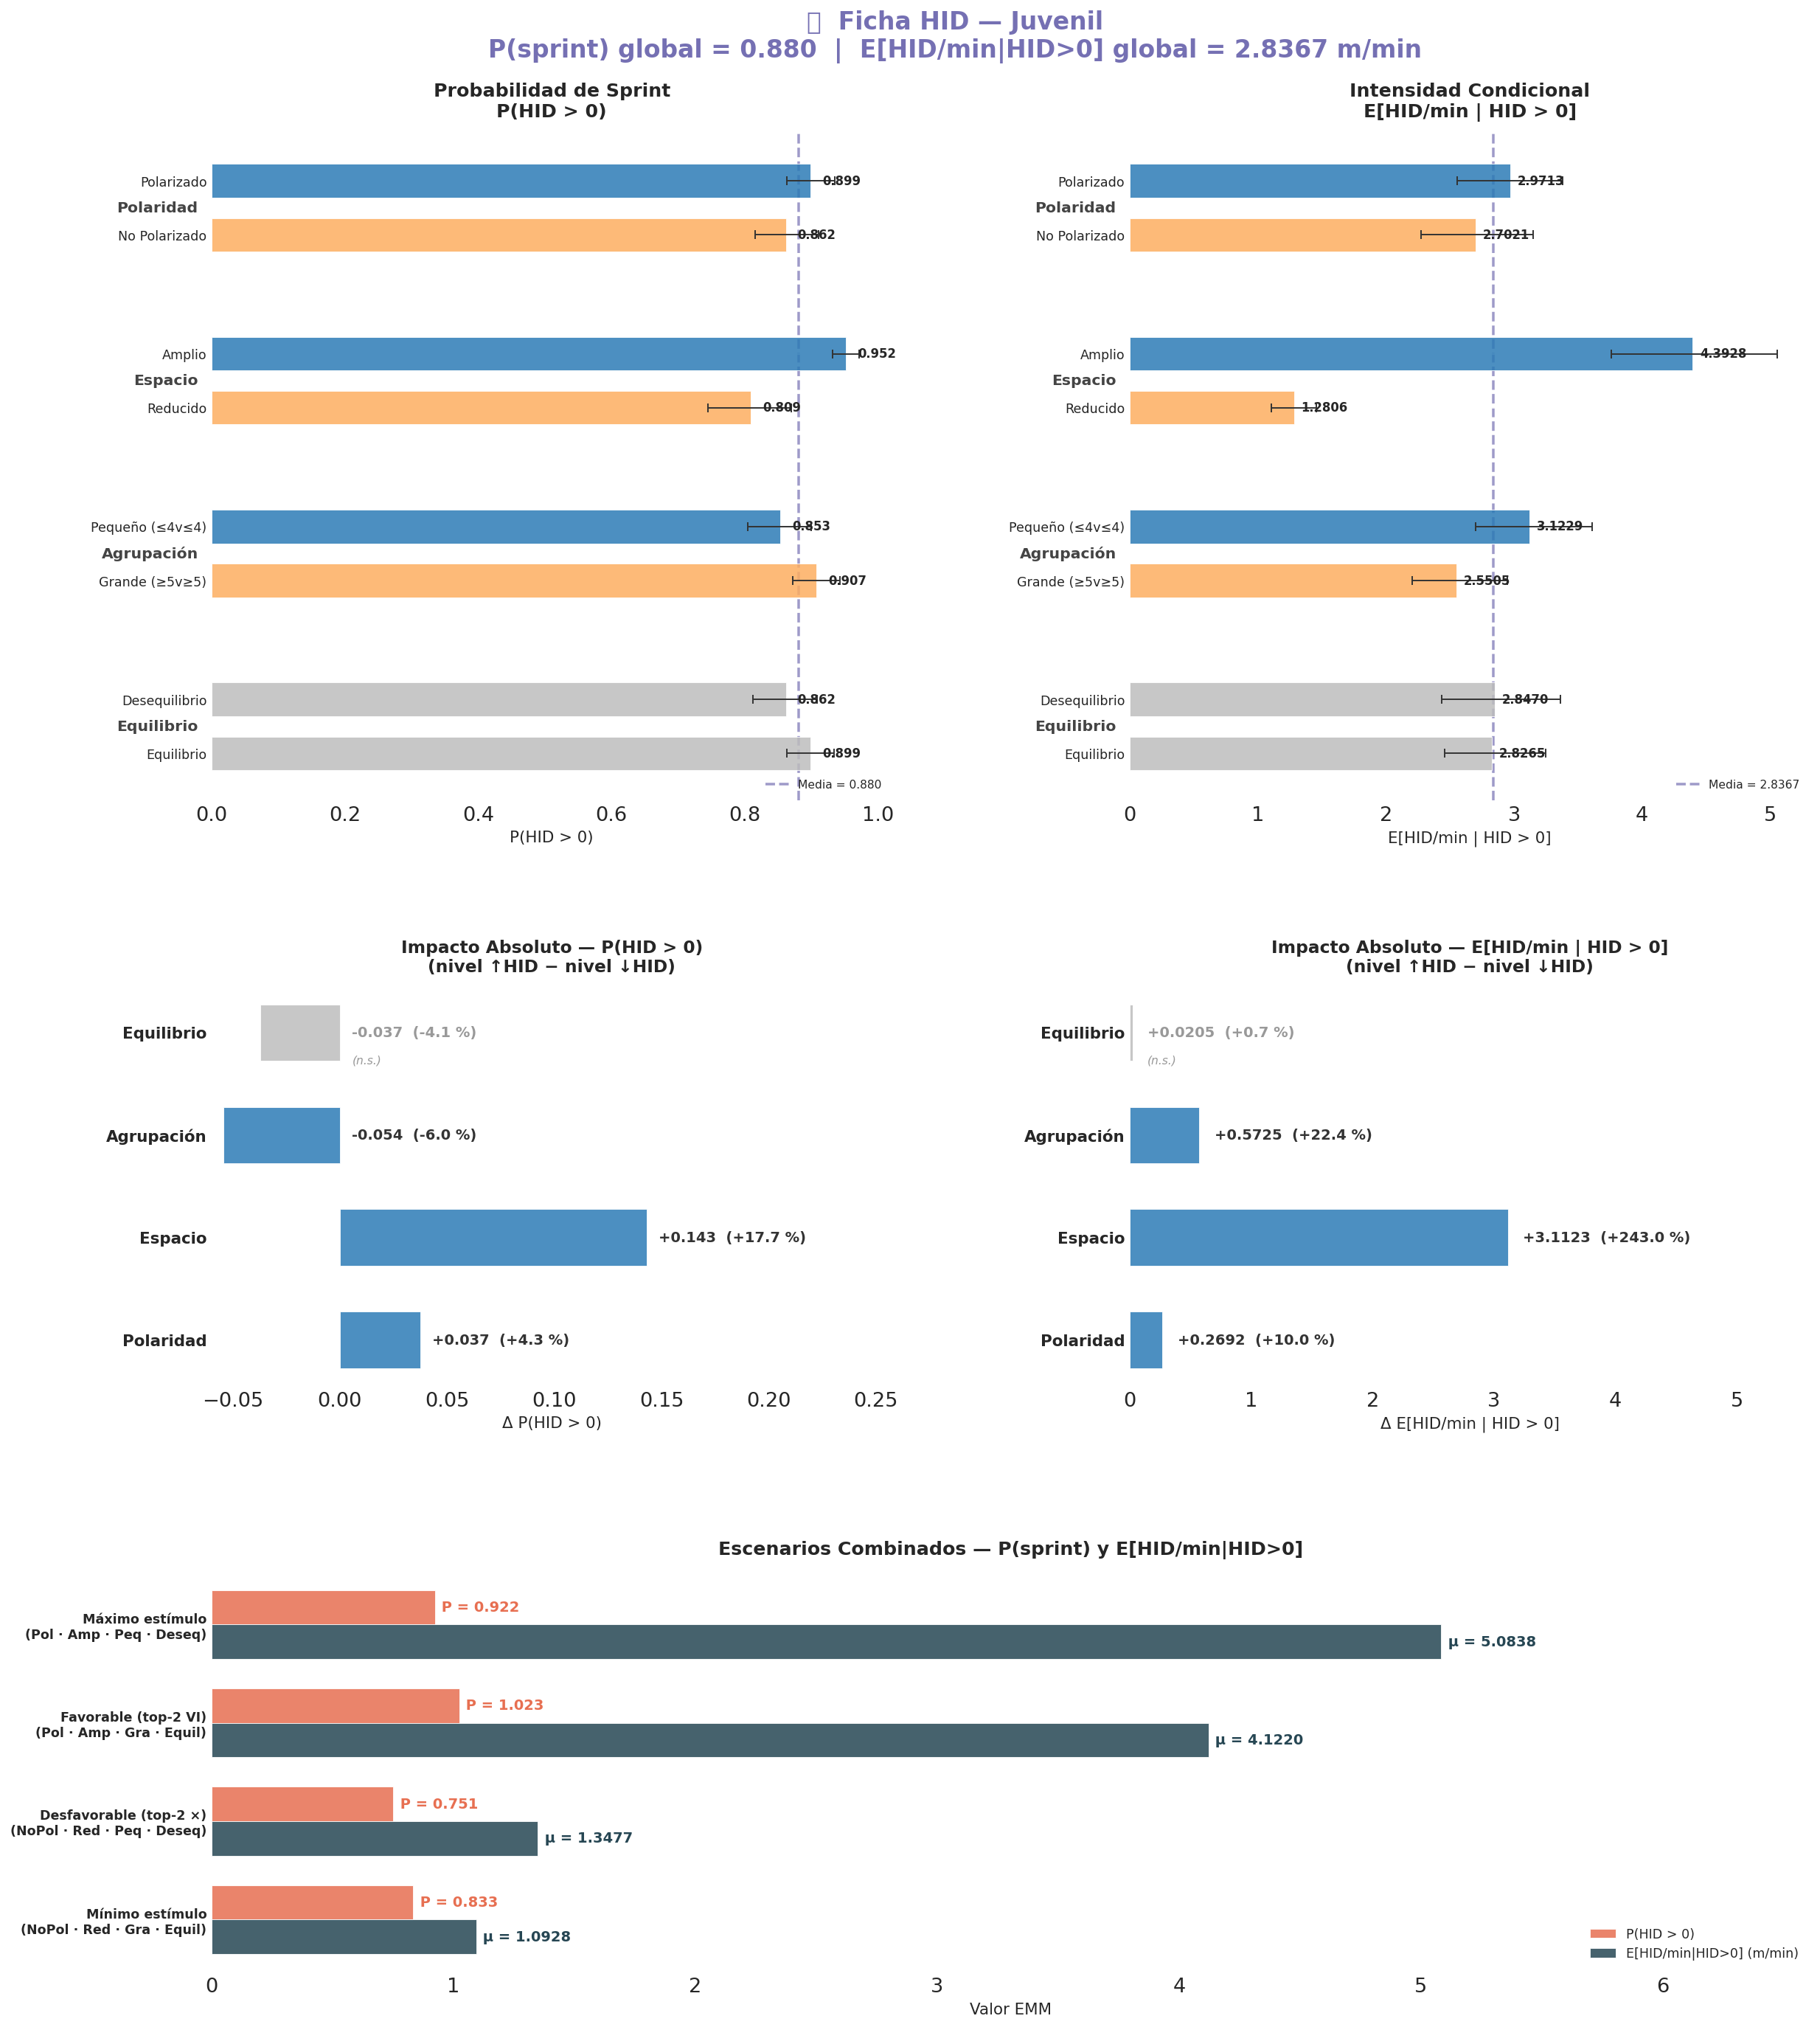


════════════════════════════════════════════════════════════════════════════════
  2 · Senior Masculino
      P(HID>0) = 0.876 [0.835, 0.913]
      E[HID/min|HID>0] = 3.6110 [3.1301, 4.0773] m/min
════════════════════════════════════════════════════════════════════════════════


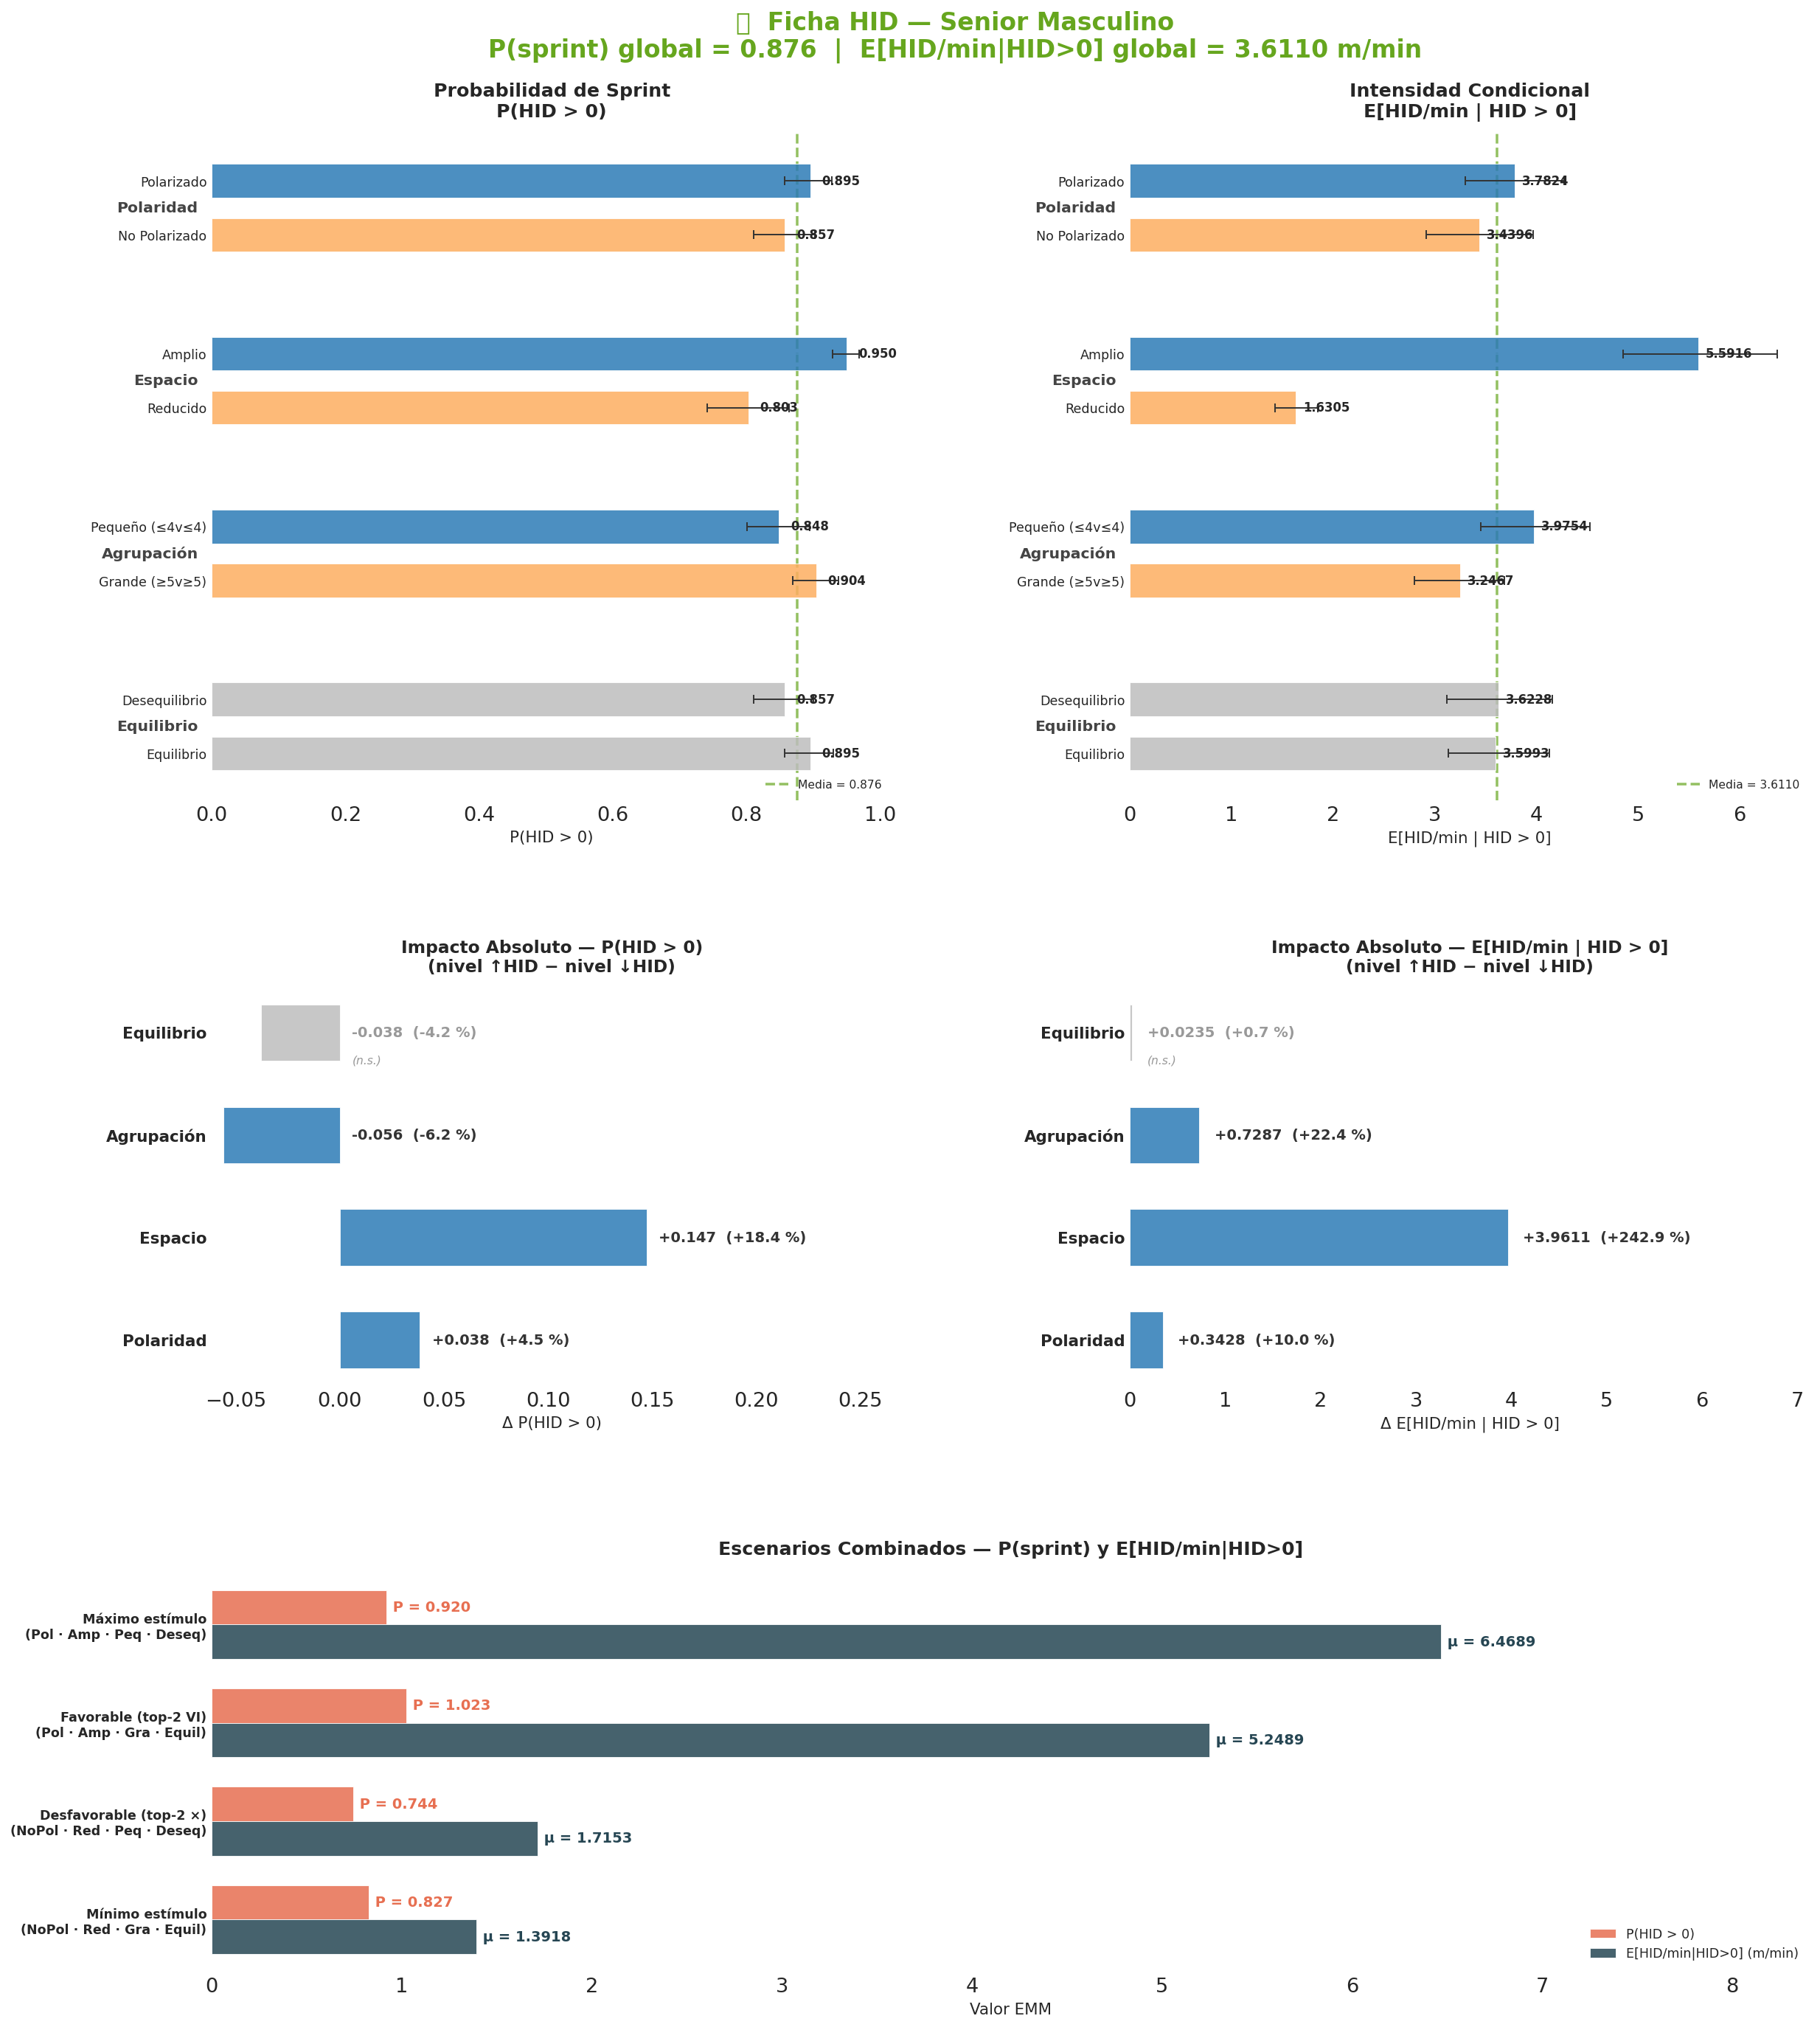


════════════════════════════════════════════════════════════════════════════════
  3 · Cadete
      P(HID>0) = 0.652 [0.567, 0.734]
      E[HID/min|HID>0] = 1.6099 [1.3412, 1.8822] m/min
════════════════════════════════════════════════════════════════════════════════


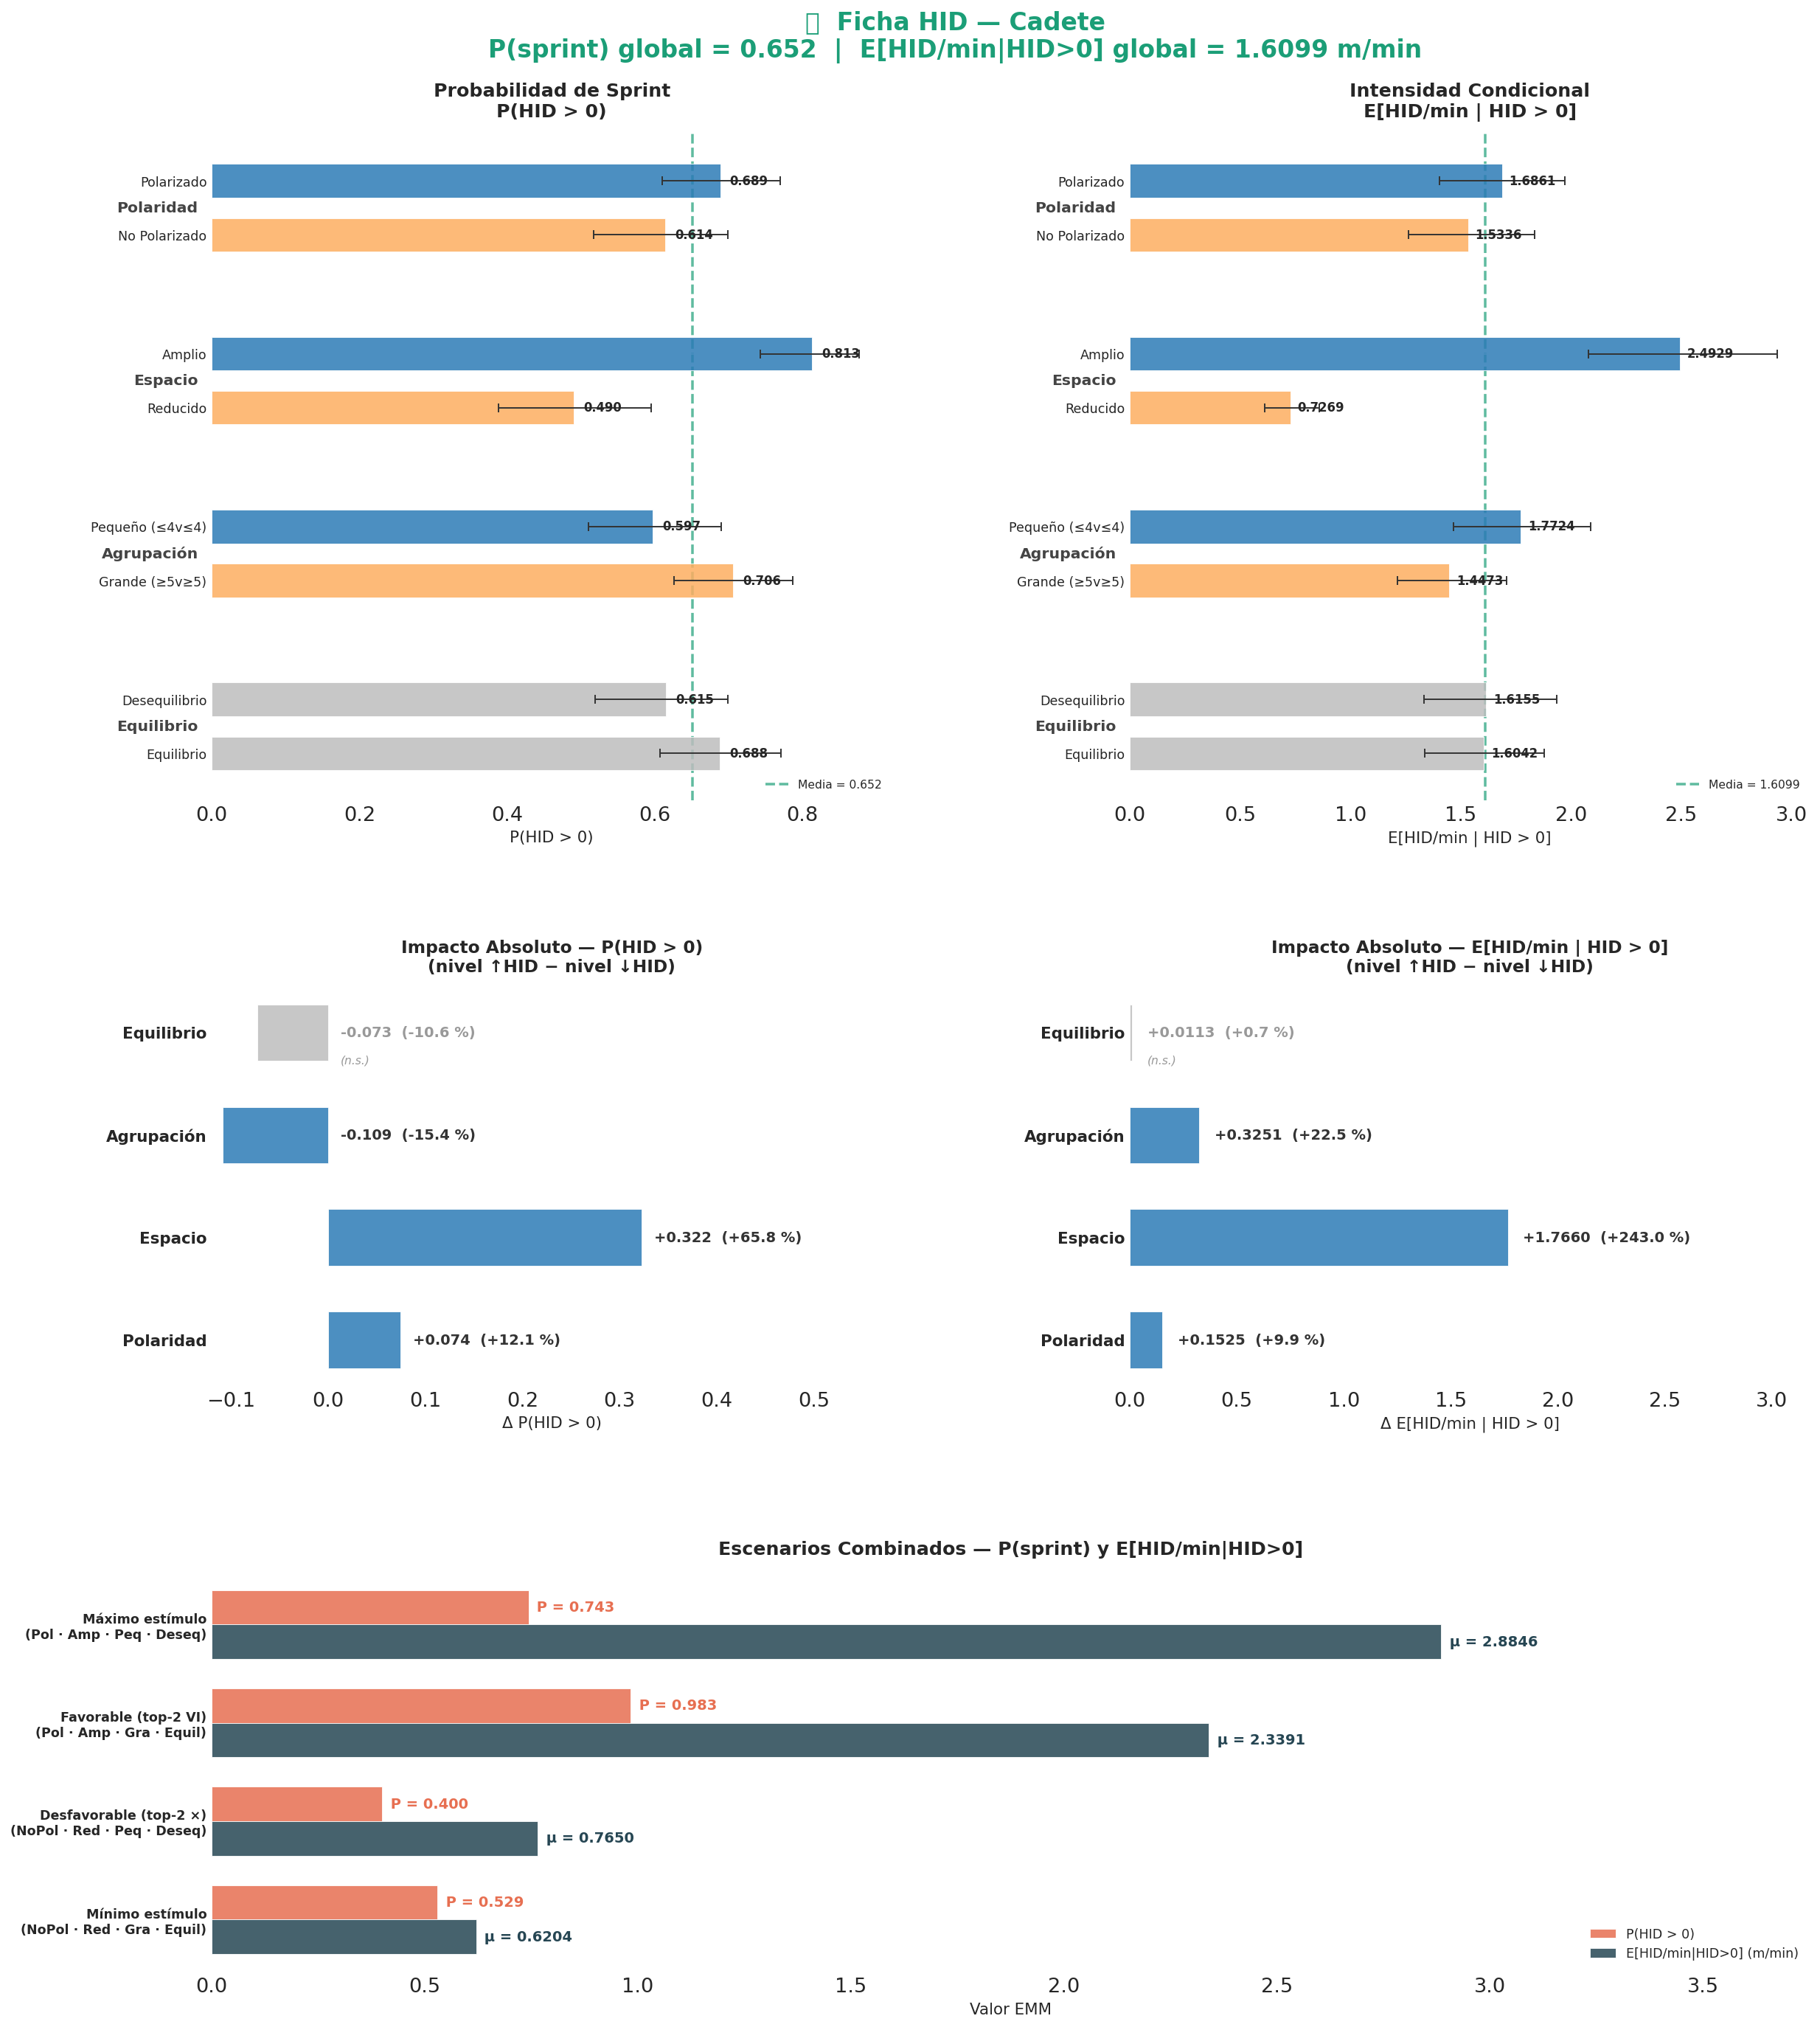


════════════════════════════════════════════════════════════════════════════════
  4 · Neskak
      P(HID>0) = 0.487 [0.409, 0.571]
      E[HID/min|HID>0] = 1.2255 [1.0522, 1.4065] m/min
════════════════════════════════════════════════════════════════════════════════


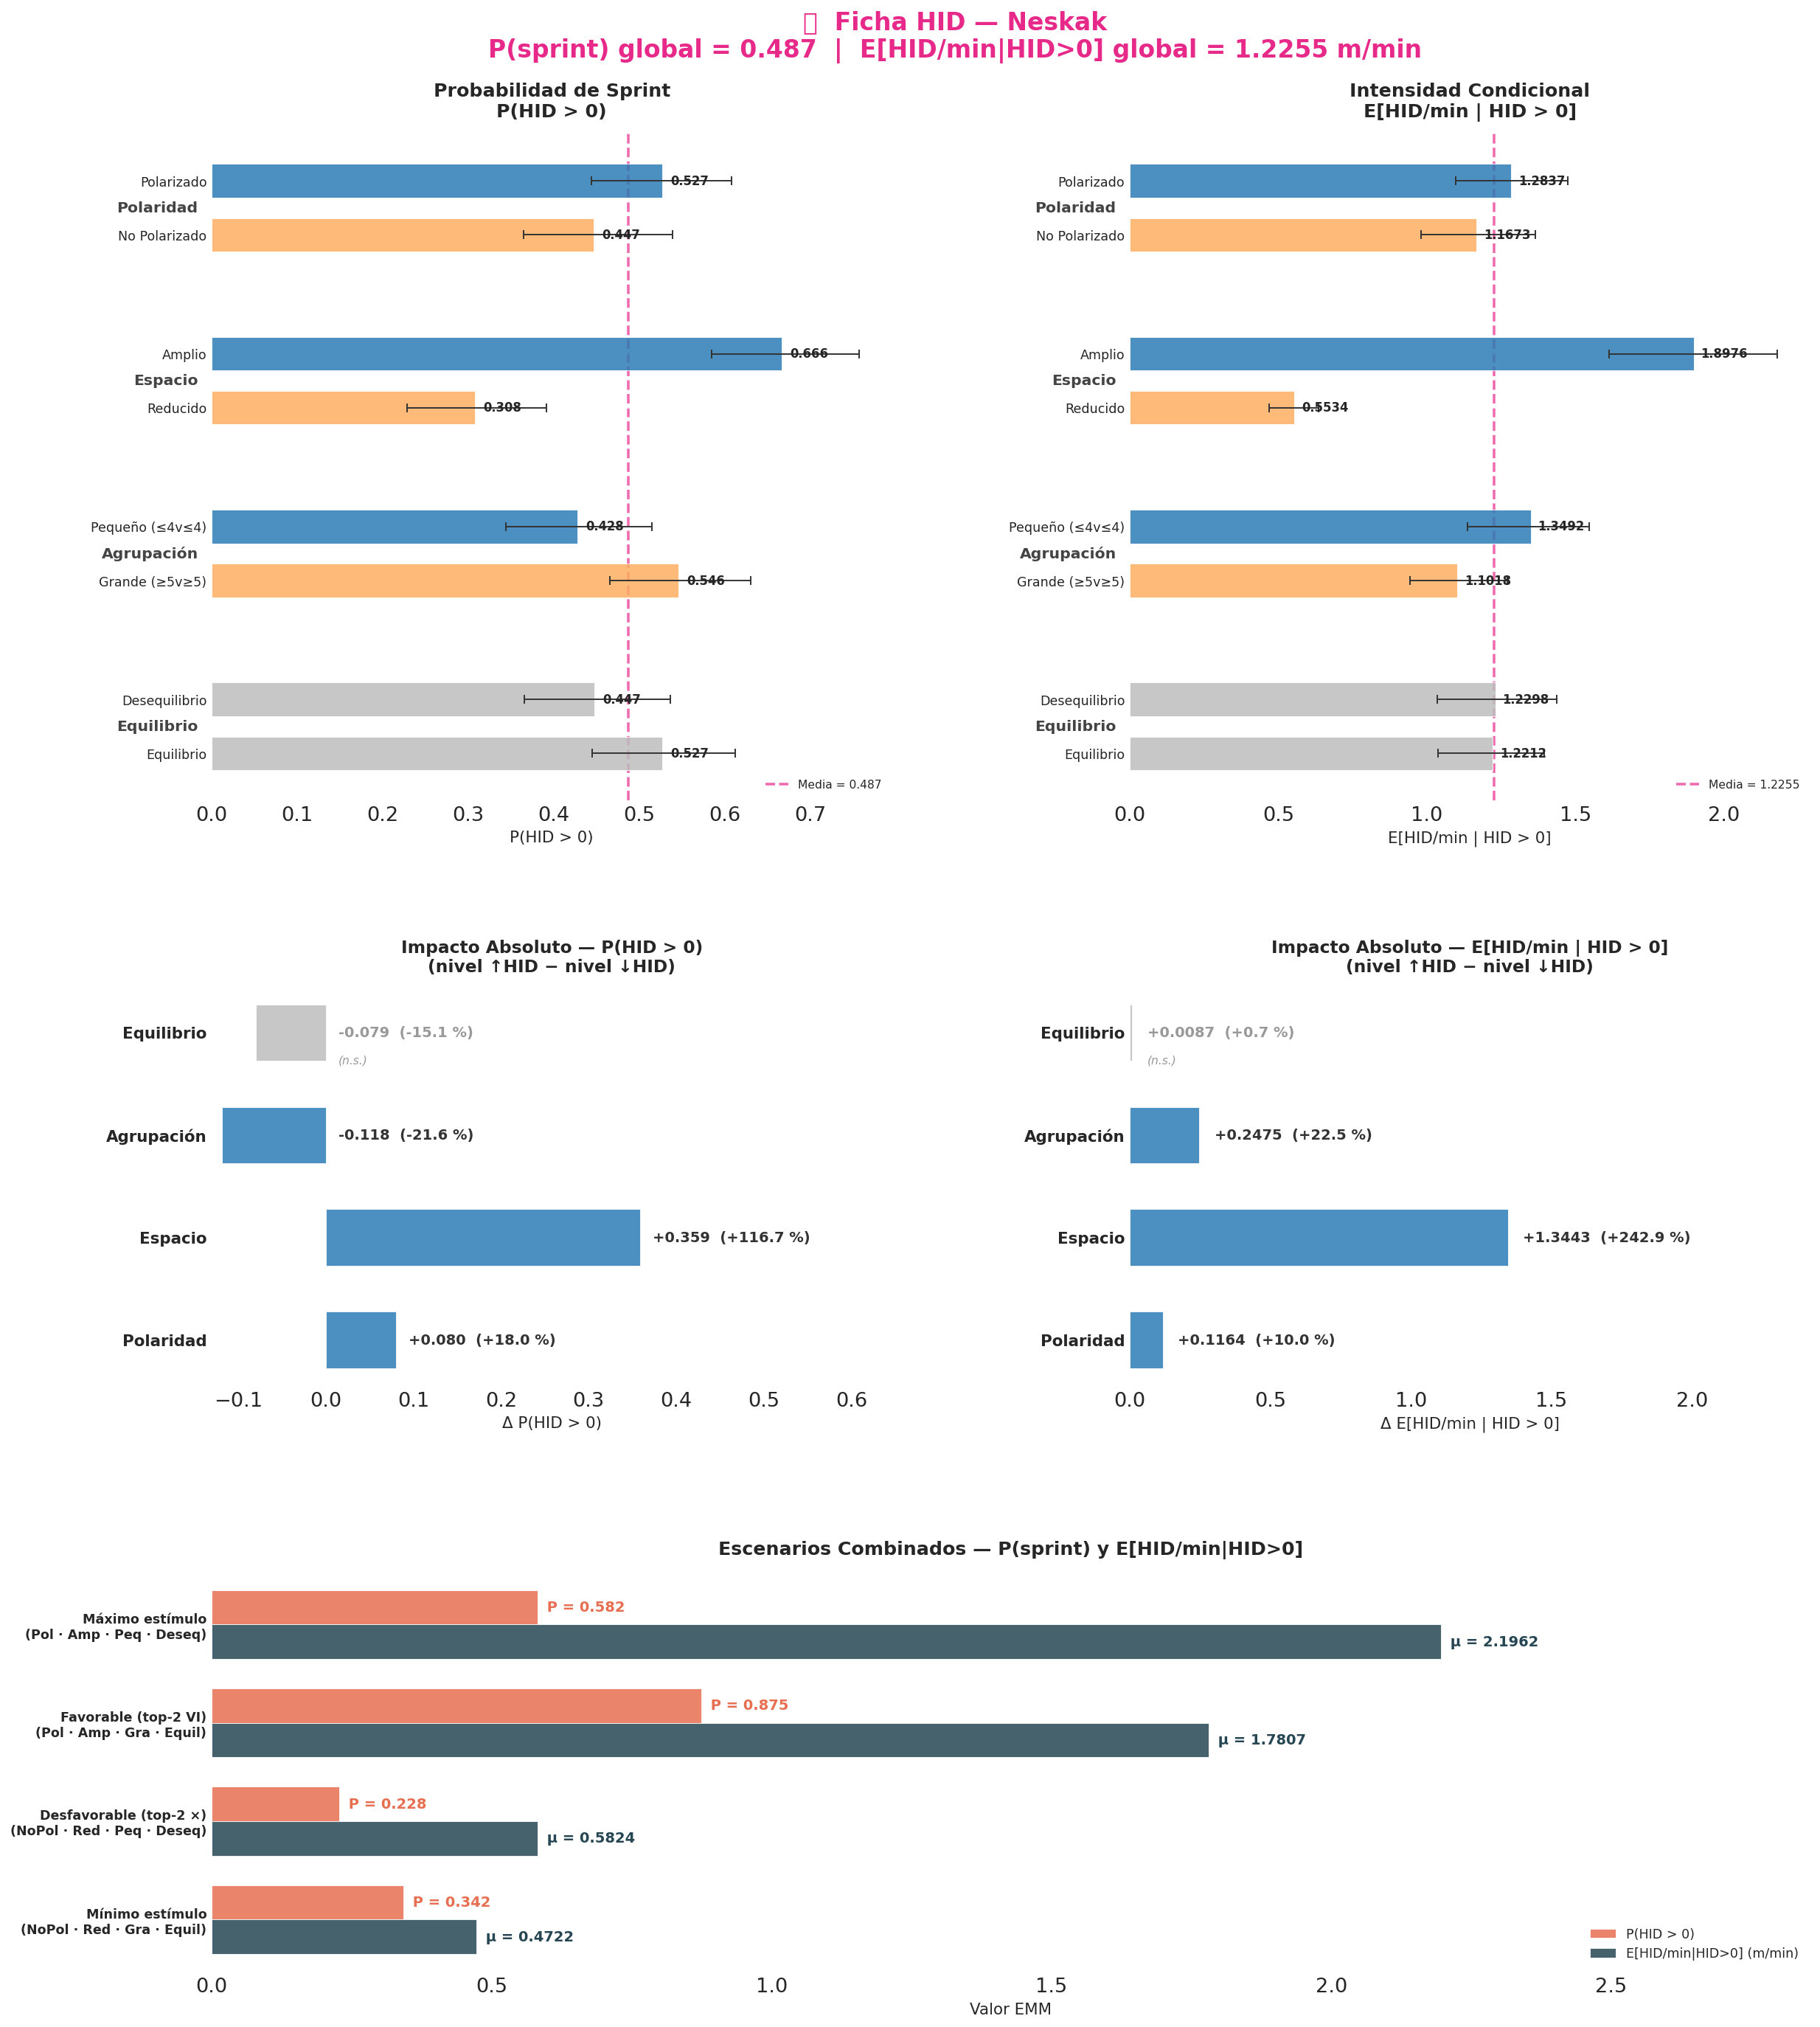


════════════════════════════════════════════════════════════════════════════════
  5 · Infantil
      P(HID>0) = 0.457 [0.361, 0.548]
      E[HID/min|HID>0] = 1.2765 [1.0456, 1.5171] m/min
════════════════════════════════════════════════════════════════════════════════


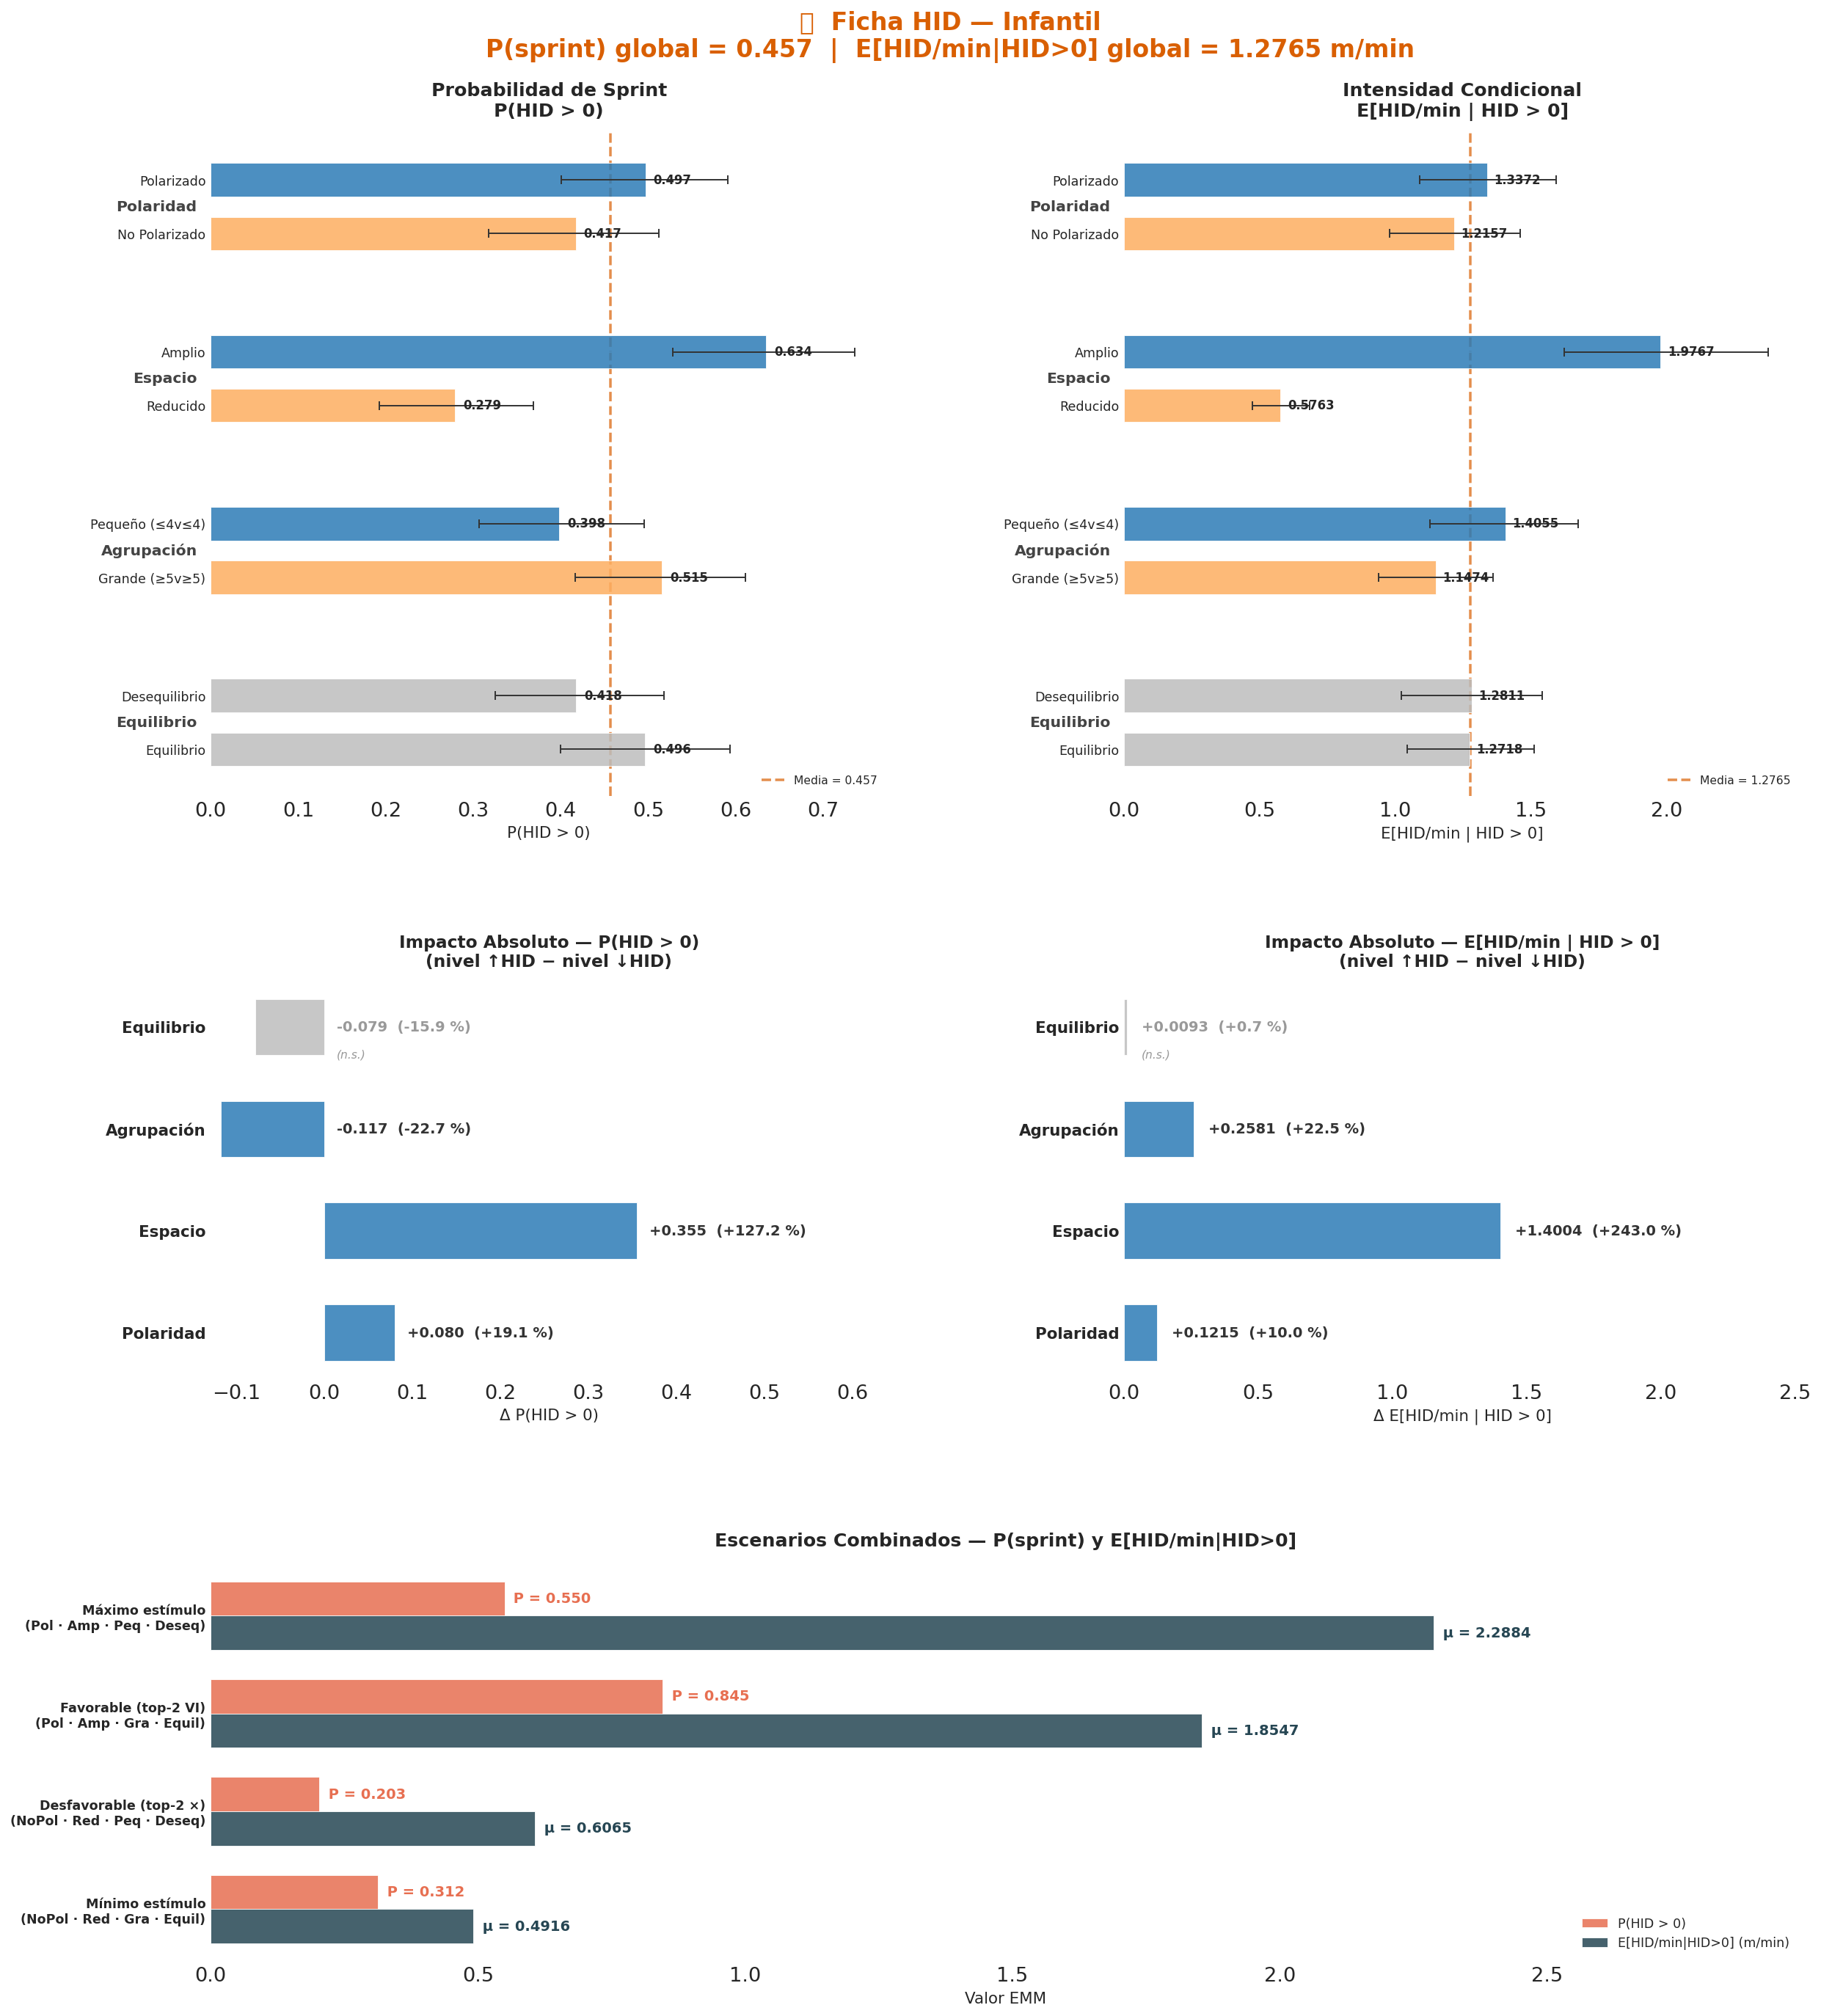

In [10]:
# ── Generar una ficha por cada categoría de edad ─────────────────────────
fichas = {}
for i, cat in enumerate(orden_categorias, 1):
    mp, lop, hip = emm_global[cat]["psi"]
    mm, lom, him = emm_global[cat]["mu"]
    print(f"\n{'═' * 80}")
    print(f"  {i} · {cat}")
    print(f"      P(HID>0) = {mp:.3f} [{lop:.3f}, {hip:.3f}]")
    print(f"      E[HID/min|HID>0] = {mm:.4f} [{lom:.4f}, {him:.4f}] m/min")
    print(f"{'═' * 80}")
    fichas[cat] = generar_ficha(cat)

---
## 6 · Comparación entre Categorías

Visión conjunta que compara los **niveles base** y los **Δ de impacto** de cada
grupo de edad, mostrando por separado los dos procesos del Hurdle:

- **P(HID > 0)**: ¿Qué categorías tienen mayor probabilidad de carrera de alta intensidad?
- **E[HID/min | HID > 0]**: ¿Qué categorías acumulan más distancia a alta intensidad?
- **Heatmaps de Δ**: ¿Qué VI impactan más en cada parte y grupo?

**Hallazgo esperado**: El gradiente por categoría en HID/min es el más pronunciado
de las 4 VD (de ~0.70 m/min en Infantil a ~3.18 m/min en categorías superiores).
La parte ψ también diferirá más entre categorías que en Golpeos, porque los
jugadores más jóvenes en espacios reducidos rara vez alcanzan el umbral de 4 m/s.

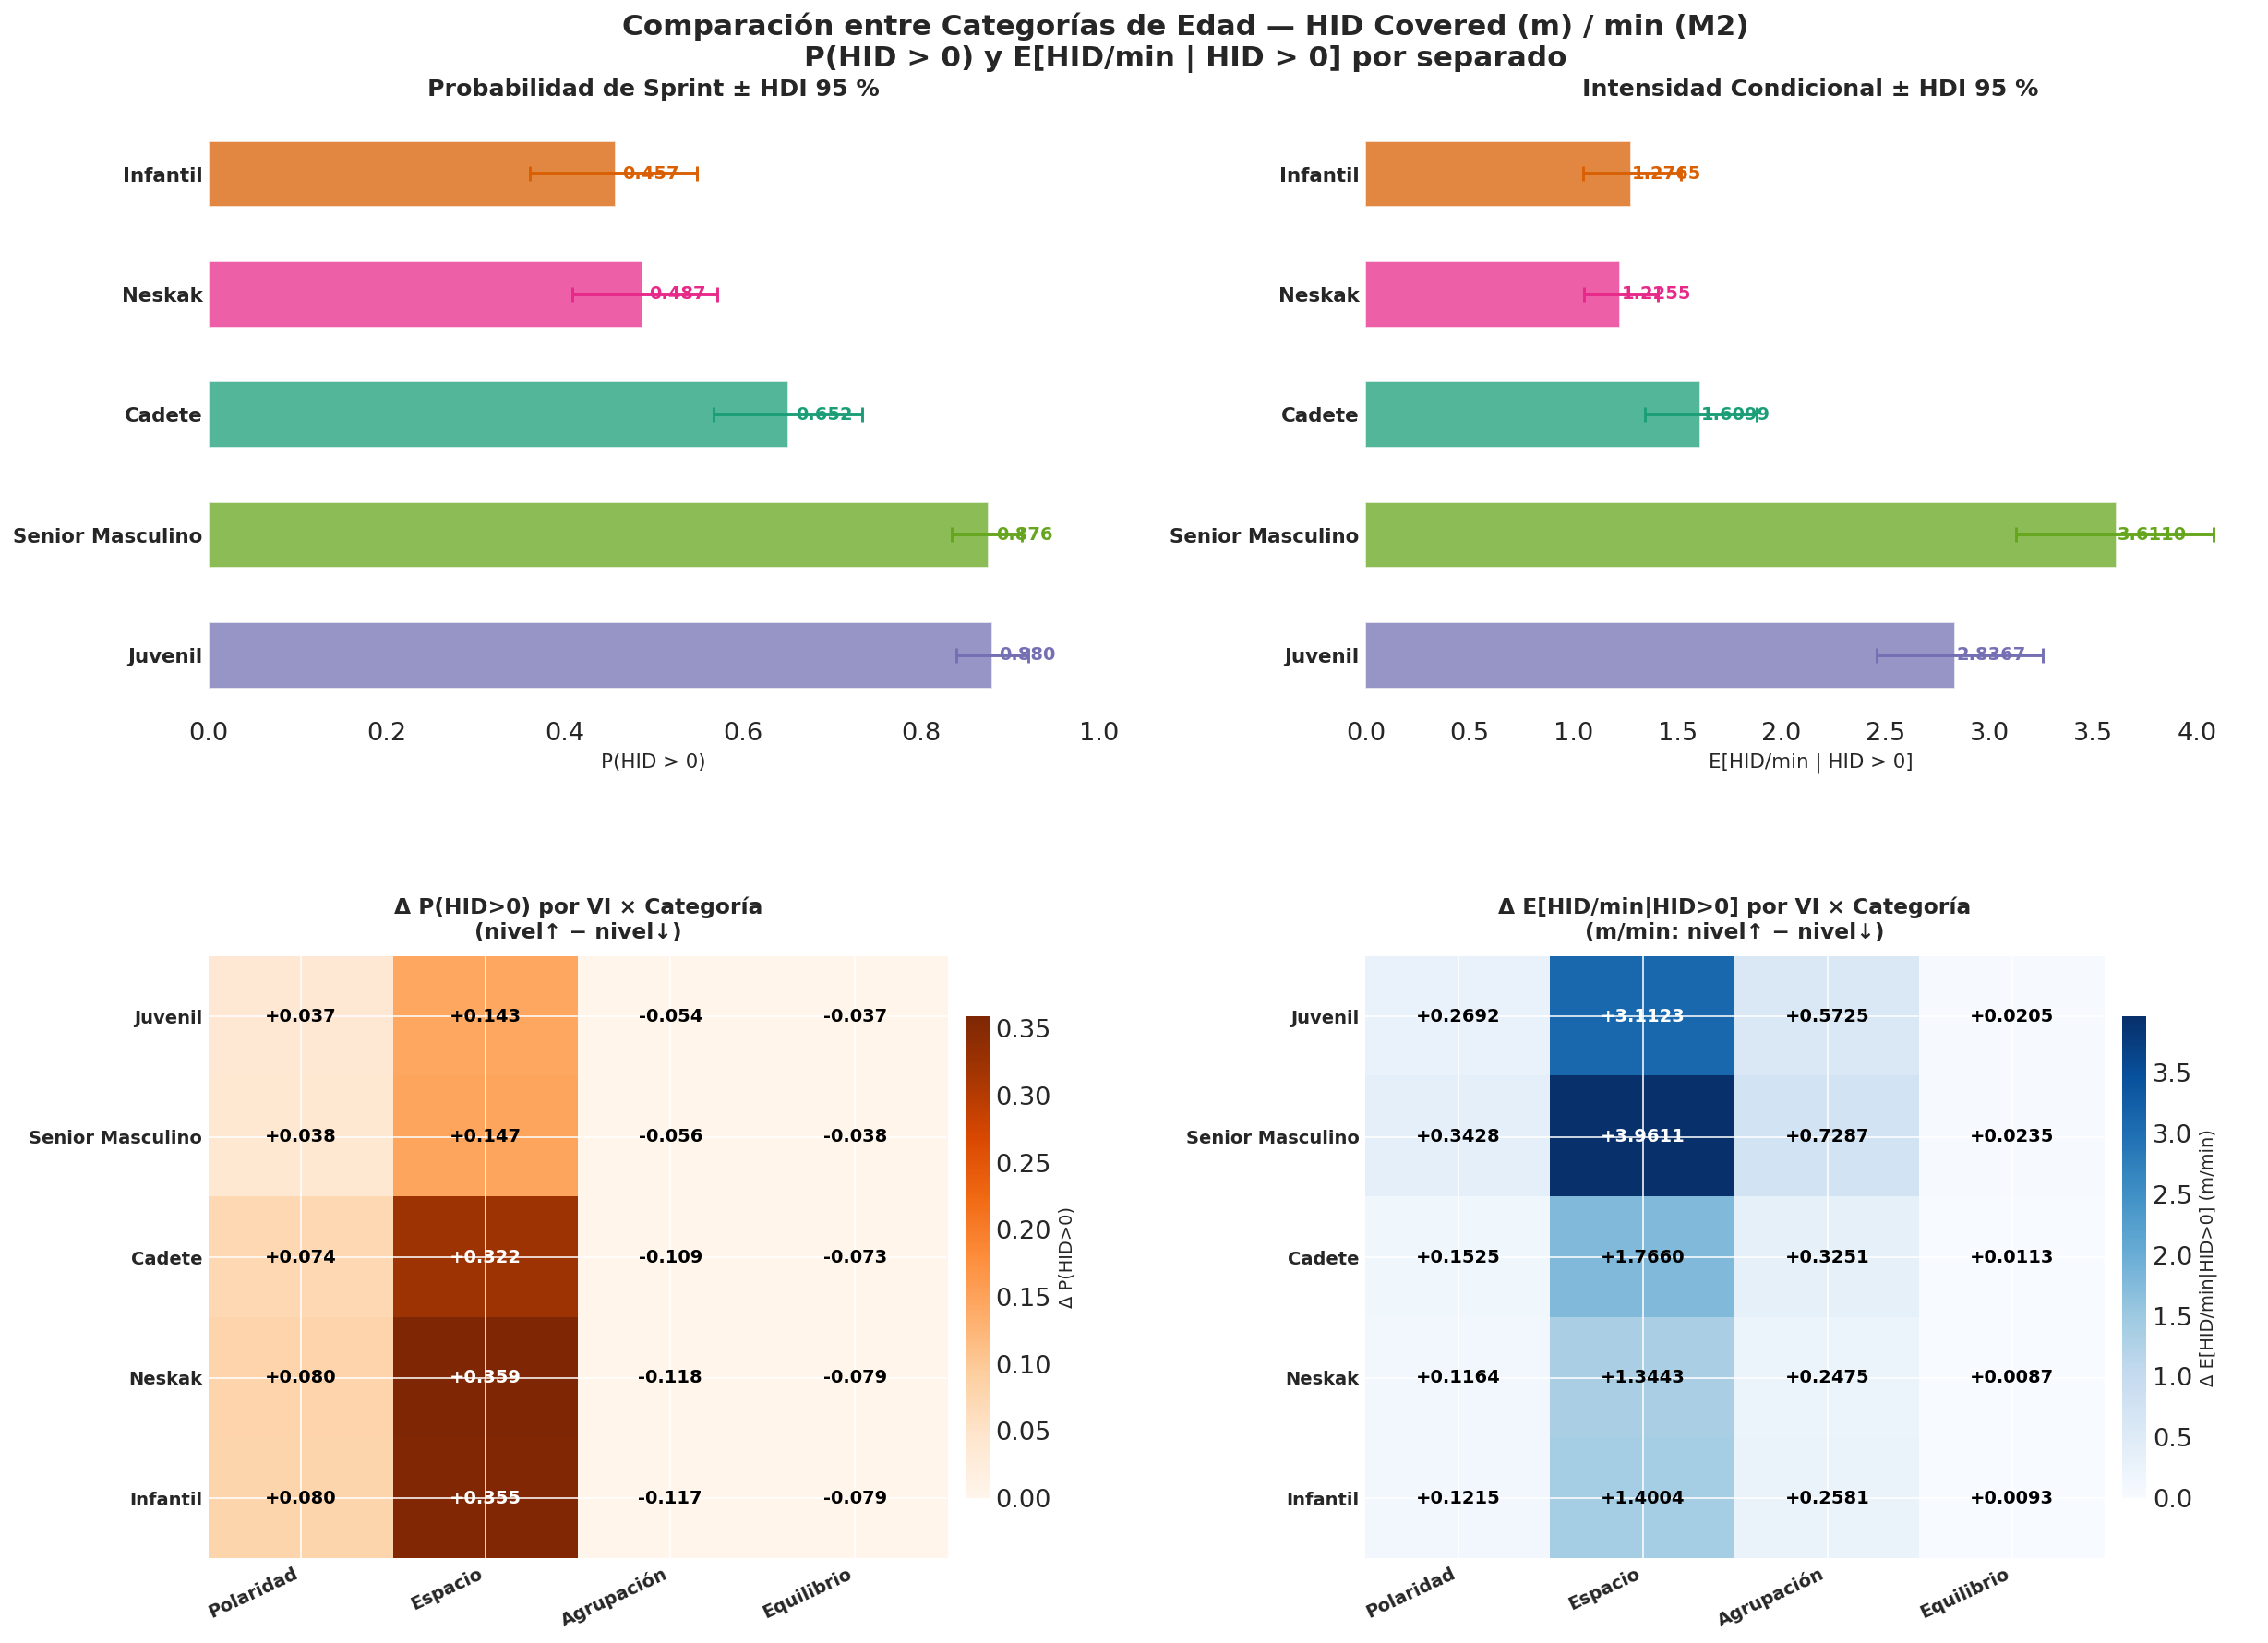

In [11]:
# ══════════════════════════════════════════════════════════════════════════
#  COMPARACIÓN ENTRE CATEGORÍAS — 4 paneles (2×2): P(HID>0) y E[HID/min|HID>0]
# ══════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 13), facecolor="white")
gs_comp = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.30,
                             left=0.08, right=0.96, top=0.92, bottom=0.06)

fig.suptitle("Comparación entre Categorías de Edad — HID Covered (m) / min (M2)\n"
             "P(HID > 0) y E[HID/min | HID > 0] por separado",
             fontsize=16, fontweight="bold", y=0.98)

# ── Panel A (arriba-izq): P(HID>0) global por categoría ─────────────────
ax = fig.add_subplot(gs_comp[0, 0])
for i, cat in enumerate(orden_categorias):
    mp, lop, hip = emm_global[cat]["psi"]
    color = colores_cat[cat]
    ax.barh(i, mp, height=0.55, color=color, alpha=0.75, edgecolor="white")
    ax.errorbar(mp, i, xerr=[[mp - lop], [hip - mp]], fmt="none",
                ecolor=color, elinewidth=2, capsize=4, capthick=1.5)
    ax.text(mp + 0.008, i, f"{mp:.3f}", fontsize=10, fontweight="bold",
            color=color, va="center")

ax.set_yticks(range(len(orden_categorias)))
ax.set_yticklabels(orden_categorias, fontsize=11, fontweight="bold")
ax.set_xlabel("P(HID > 0)", fontsize=11)
ax.set_title("Probabilidad de Sprint ± HDI 95 %", fontsize=13, fontweight="bold", pad=10)
ax.grid(axis="x", alpha=0.25, ls=":")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(left=0, right=1.0)

# ── Panel B (arriba-der): E[HID/min|HID>0] global por categoría ─────────
ax2 = fig.add_subplot(gs_comp[0, 1])
for i, cat in enumerate(orden_categorias):
    mm, lom, him = emm_global[cat]["mu"]
    color = colores_cat[cat]
    ax2.barh(i, mm, height=0.55, color=color, alpha=0.75, edgecolor="white")
    ax2.errorbar(mm, i, xerr=[[mm - lom], [him - mm]], fmt="none",
                 ecolor=color, elinewidth=2, capsize=4, capthick=1.5)
    ax2.text(mm + 0.005, i, f"{mm:.4f}", fontsize=10, fontweight="bold",
             color=color, va="center")

ax2.set_yticks(range(len(orden_categorias)))
ax2.set_yticklabels(orden_categorias, fontsize=11, fontweight="bold")
ax2.set_xlabel("E[HID/min | HID > 0]", fontsize=11)
ax2.set_title("Intensidad Condicional ± HDI 95 %", fontsize=13, fontweight="bold", pad=10)
ax2.grid(axis="x", alpha=0.25, ls=":")
ax2.spines[["top", "right"]].set_visible(False)
ax2.set_xlim(left=0)

# ── Panel C (abajo-izq): Heatmap Δ P(HID>0) por VI × Categoría ─────────
ax3 = fig.add_subplot(gs_comp[1, 0])
delta_psi_matrix = np.zeros((len(orden_categorias), len(orden_vi)))
for i, cat in enumerate(orden_categorias):
    for j, vi in enumerate(orden_vi):
        b = emm_vi_ge[cat][vi][nivel_boost[vi]]["psi"][0]
        r = emm_vi_ge[cat][vi][nivel_reduce[vi]]["psi"][0]
        delta_psi_matrix[i, j] = b - r

im3 = ax3.imshow(delta_psi_matrix, cmap="Oranges", aspect="auto", vmin=0)
ax3.set_xticks(range(len(orden_vi)))
ax3.set_xticklabels(orden_vi, fontsize=10, fontweight="bold", rotation=25, ha="right")
ax3.set_yticks(range(len(orden_categorias)))
ax3.set_yticklabels(orden_categorias, fontsize=10, fontweight="bold")
ax3.set_title("Δ P(HID>0) por VI × Categoría\n(nivel↑ − nivel↓)",
              fontsize=12, fontweight="bold", pad=10)
for i in range(len(orden_categorias)):
    for j in range(len(orden_vi)):
        val = delta_psi_matrix[i, j]
        txt_color = "white" if val > delta_psi_matrix.max() * 0.6 else "black"
        ax3.text(j, i, f"{val:+.3f}", ha="center", va="center",
                 fontsize=10, fontweight="bold", color=txt_color)
cb3 = fig.colorbar(im3, ax=ax3, shrink=0.8, pad=0.02)
cb3.set_label("Δ P(HID>0)", fontsize=10)

# ── Panel D (abajo-der): Heatmap Δ E[HID/min|HID>0] por VI × Categoría ─
ax4 = fig.add_subplot(gs_comp[1, 1])
delta_mu_matrix = np.zeros((len(orden_categorias), len(orden_vi)))
for i, cat in enumerate(orden_categorias):
    for j, vi in enumerate(orden_vi):
        b = emm_vi_ge[cat][vi][nivel_boost[vi]]["mu"][0]
        r = emm_vi_ge[cat][vi][nivel_reduce[vi]]["mu"][0]
        delta_mu_matrix[i, j] = b - r

im4 = ax4.imshow(delta_mu_matrix, cmap="Blues", aspect="auto", vmin=0)
ax4.set_xticks(range(len(orden_vi)))
ax4.set_xticklabels(orden_vi, fontsize=10, fontweight="bold", rotation=25, ha="right")
ax4.set_yticks(range(len(orden_categorias)))
ax4.set_yticklabels(orden_categorias, fontsize=10, fontweight="bold")
ax4.set_title("Δ E[HID/min|HID>0] por VI × Categoría\n(m/min: nivel↑ − nivel↓)",
              fontsize=12, fontweight="bold", pad=10)
for i in range(len(orden_categorias)):
    for j in range(len(orden_vi)):
        val = delta_mu_matrix[i, j]
        txt_color = "white" if val > delta_mu_matrix.max() * 0.6 else "black"
        ax4.text(j, i, f"{val:+.4f}", ha="center", va="center",
                 fontsize=10, fontweight="bold", color=txt_color)
cb4 = fig.colorbar(im4, ax=ax4, shrink=0.8, pad=0.02)
cb4.set_label("Δ E[HID/min|HID>0] (m/min)", fontsize=10)

plt.show()

---
## 7 · Los 16 Escenarios Combinados de Diseño (2⁴)

Con 4 variables de diseño × 2 niveles cada una, existen **16 combinaciones
posibles** de diseño de tarea. Se muestran con **ambas métricas** separadas:
P(HID > 0) y E[HID/min | HID > 0].

| Abreviatura | Variable | Nivel |
|:-----------:|----------|-------|
| **Pol / NoPol** | Polaridad | Polarizado / No Polarizado |
| **Amp / Red** | Espacio | Amplio / Reducido |
| **Peq / Gra** | Agrupación | Pequeño (≤4v≤4) / Grande (≥5v≥5) |
| **Deseq / Equil** | Equilibrio | Desequilibrio / Equilibrio |

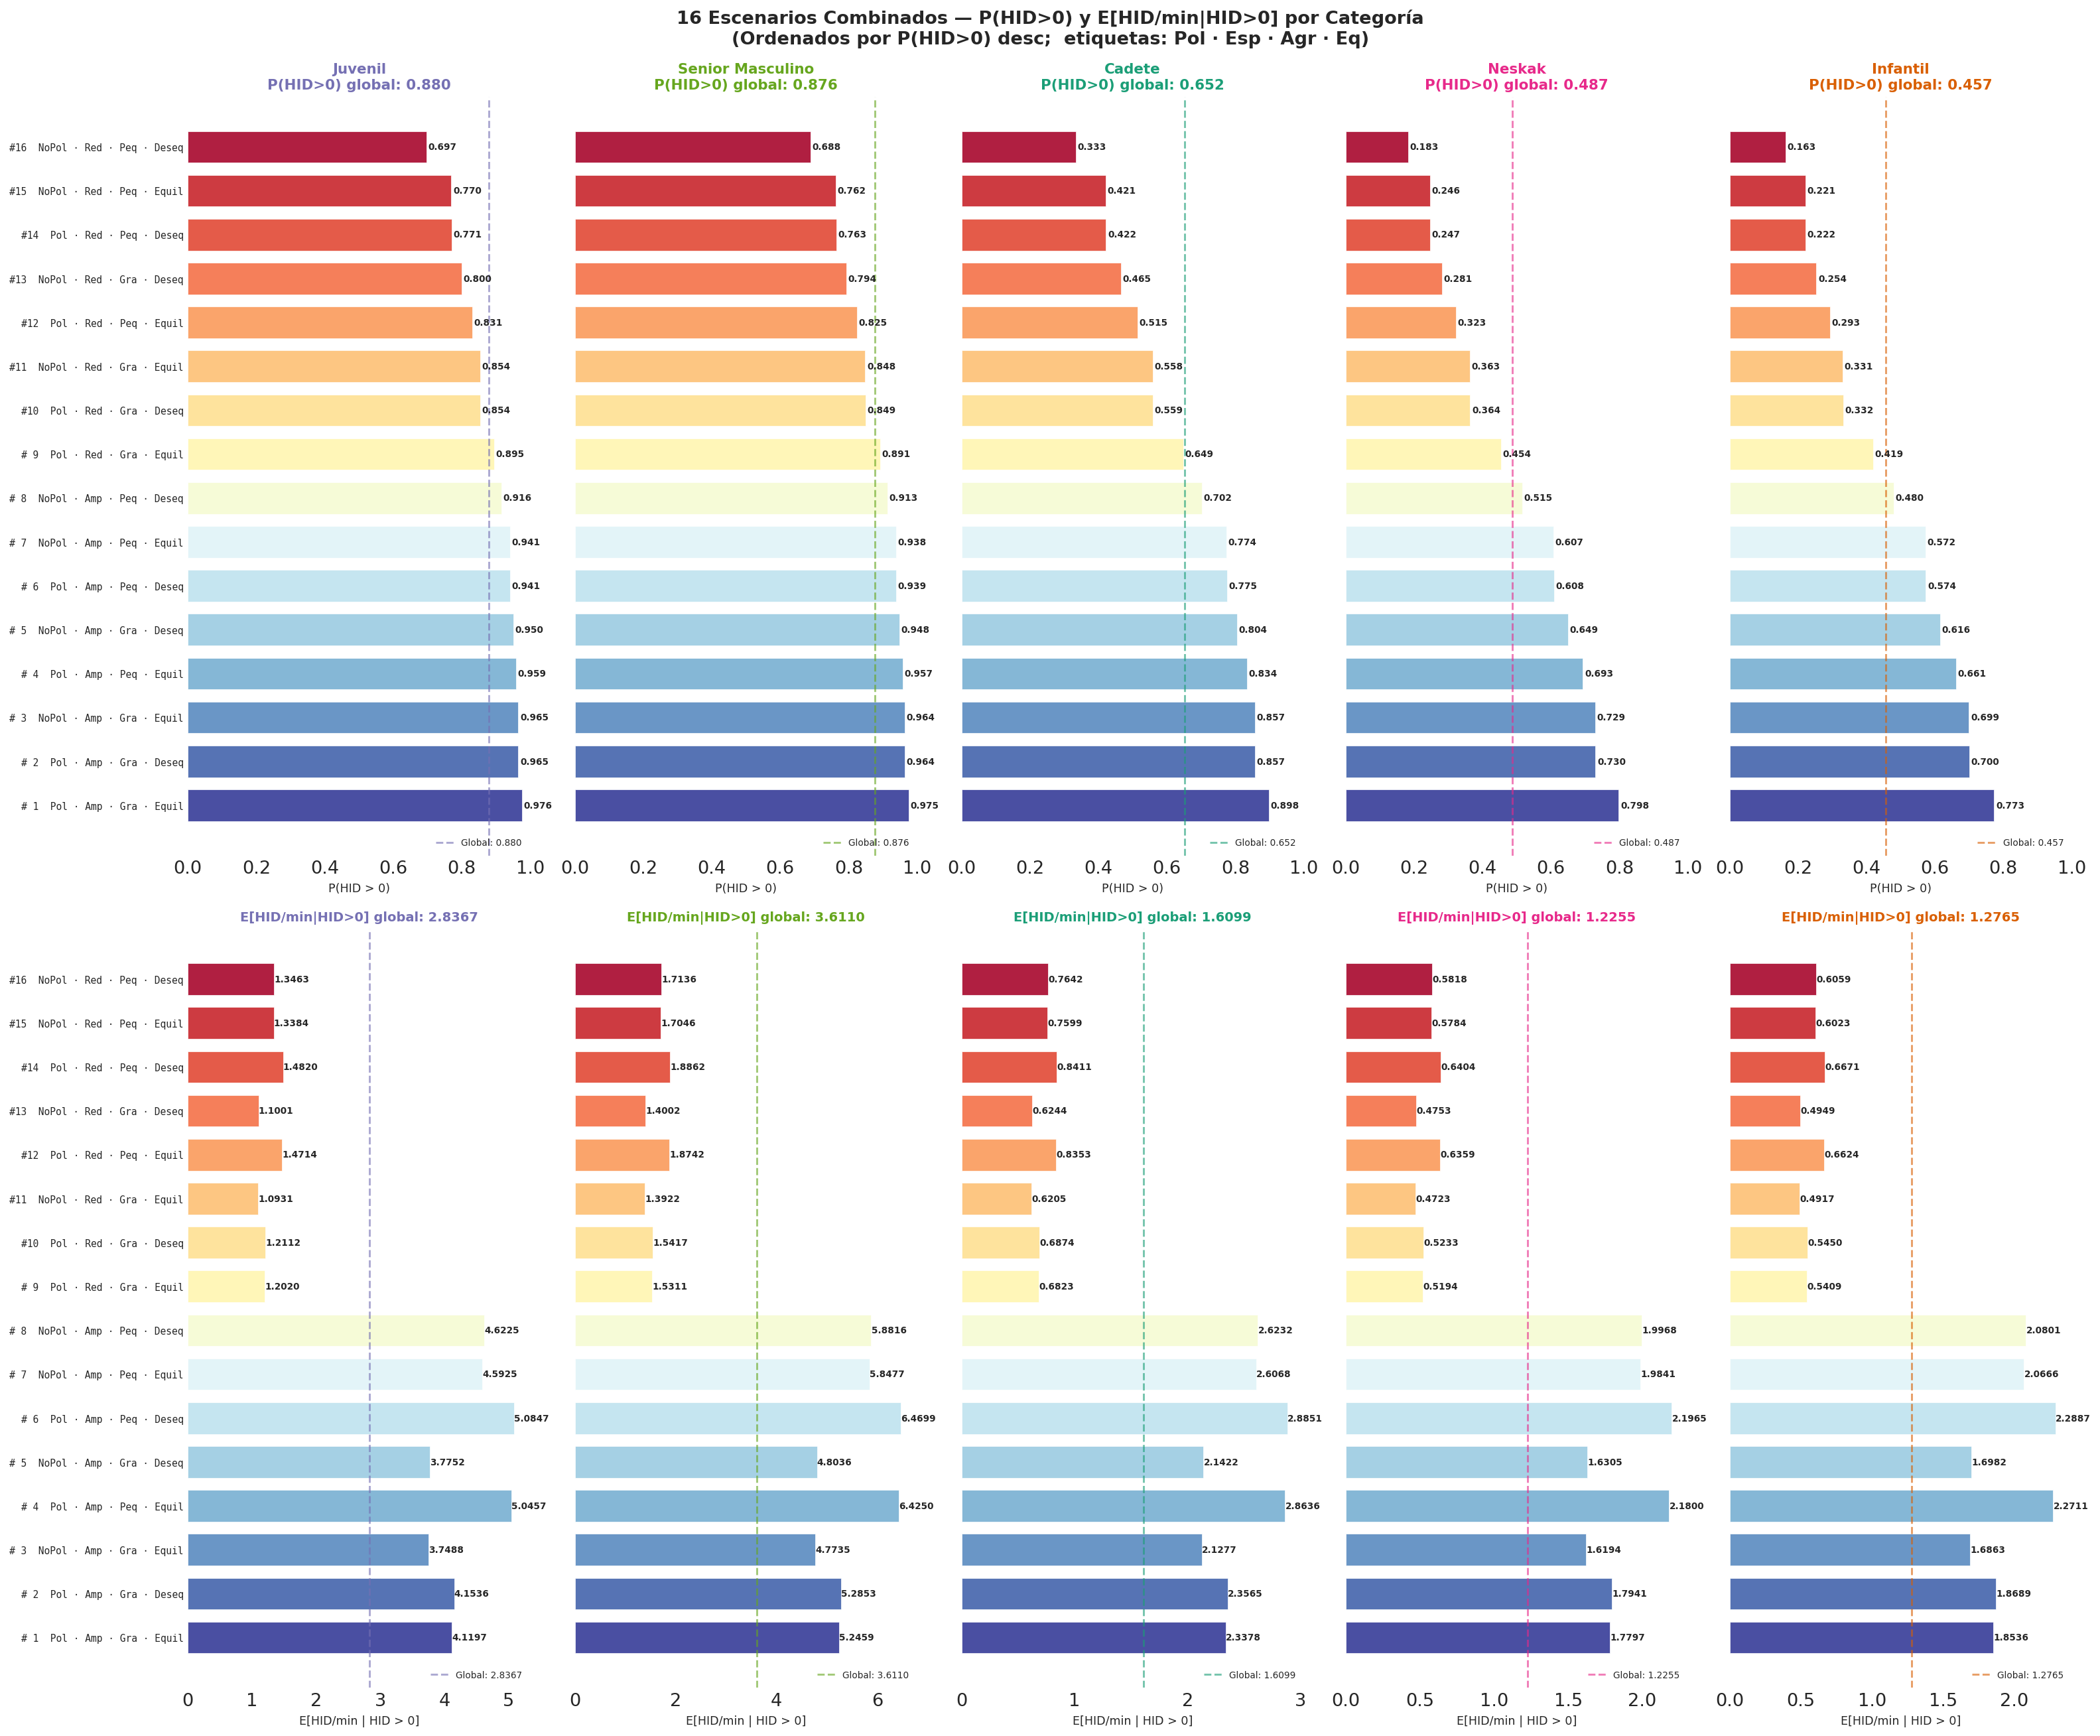


  # Escenario                           ↑  P(HID>0)  E[HID|>0]  P(HID>0)  E[HID|>0]  P(HID>0)  E[HID|>0]  P(HID>0)  E[HID|>0]  P(HID>0)  E[HID|>0]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1 Pol · Amp · Gra · Equil             2     0.976     4.1197     0.975     5.2459     0.898     2.3378     0.798     1.7797     0.773     1.8536
  2 Pol · Amp · Gra · Deseq             3     0.965     4.1536     0.964     5.2853     0.857     2.3565     0.730     1.7941     0.700     1.8689
  3 NoPol · Amp · Gra · Equil           1     0.965     3.7488     0.964     4.7735     0.857     2.1277     0.729     1.6194     0.699     1.6863
  4 Pol · Amp · Peq · Equil             3     0.959     5.0457     0.957     6.4250     0.834     2.8636     0.693     2.1800     0.661     2.2711
  5 NoPol · Amp · Gra · Deseq           2     0.950     3.7752     0.948     4.8036     0.804     2.1422     0.649     1.63

In [12]:
# ══════════════════════════════════════════════════════════════════════════
#  TODOS LOS 16 ESCENARIOS COMBINADOS POR CATEGORÍA DE EDAD
#  Mostrando P(HID>0) y E[HID/min|HID>0] por separado
# ══════════════════════════════════════════════════════════════════════════

abreviaturas = {
    "amplio": "Amp", "reducido": "Red",
    "grande": "Gra", "pequeño": "Peq",
    "NoPolarizado": "NoPol", "Polarizado": "Pol",
    "Desequilibrio": "Deseq", "Equilibrio": "Equil",
}

_vi_keys_label = ["Polaridad", "Espacio", "Agrupacion", "Equilibrio"]


def calcular_todos_escenarios_16(cat):
    """Calcula los 16 escenarios combinados, ordenados por P(HID>0) desc."""
    vi_keys = list(niveles_vi.keys())
    combos = list(product(*[niveles_vi[k] for k in vi_keys]))

    resultados = []
    for combo in combos:
        target = {vi_keys[i]: combo[i] for i in range(len(vi_keys))}
        s_psi, s_mu, s_comb = calcular_emm_hurdle(
            target, betas_mu, intercept_mu, betas_psi, intercept_psi,
            niveles_vi, betas_ge_mu=betas_ge_mu, betas_ge_psi=betas_ge_psi,
            ge_level=cat
        )
        mc, loc, hic = emm_tabla(s_comb)
        mp, lop, hip = emm_tabla(s_psi)
        mm, lom, him = emm_tabla(s_mu)
        label = " · ".join([abreviaturas[target[vi]] for vi in _vi_keys_label])
        n_boost = sum(1 for vk in vi_keys
                      if target[vk] == nivel_boost.get(etiquetas_vi[vk], ""))
        resultados.append({
            "label": label, "emm": mc, "lo": loc, "hi": hic,
            "psi": mp, "psi_lo": lop, "psi_hi": hip,
            "mu": mm, "mu_lo": lom, "mu_hi": him,
            "niveles": target, "n_boost": n_boost,
        })

    # Ordenar por P(HID>0) descendente
    resultados.sort(key=lambda x: x["psi"], reverse=True)
    for i, r in enumerate(resultados):
        r["rank"] = i + 1
    return resultados


# Calcular para todos los grupos
todos_esc = {cat: calcular_todos_escenarios_16(cat) for cat in orden_categorias}

# ── Visualización: 2 filas × n_cats columnas ─────────────────────────────
n_cats = len(orden_categorias)
fig, axes_arr = plt.subplots(2, n_cats, figsize=(4.5 * n_cats, 18),
                              sharey=True, facecolor="white")
if n_cats == 1:
    axes_arr = axes_arr.reshape(2, 1)

cmap_16 = plt.cm.RdYlBu_r

for idx, cat in enumerate(orden_categorias):
    esc_list = todos_esc[cat]
    n_esc = len(esc_list)
    y_pos = np.arange(n_esc)
    colors = [cmap_16(i / (n_esc - 1)) for i in range(n_esc)]

    # ── Fila 1: P(HID>0) ─────────────────────────────────────────────────
    ax_psi = axes_arr[0, idx]
    psi_vals = [e["psi"] for e in esc_list]
    ax_psi.barh(y_pos, psi_vals, height=0.72, color=colors, alpha=0.88,
                edgecolor="white", linewidth=0.4)
    for i, e in enumerate(esc_list):
        ax_psi.text(e["psi"] + 0.005, i, f"{e['psi']:.3f}", va="center",
                    fontsize=7, fontweight="bold")
    g_psi = emm_global[cat]["psi"][0]
    ax_psi.axvline(g_psi, color=colores_cat[cat], lw=1.5, ls="--", alpha=0.6,
                   label=f"Global: {g_psi:.3f}")
    ax_psi.set_title(f"{cat}\nP(HID>0) global: {g_psi:.3f}",
                     fontsize=11, fontweight="bold", color=colores_cat[cat])
    ax_psi.set_xlabel("P(HID > 0)", fontsize=9)
    ax_psi.legend(fontsize=7, loc="lower right")
    ax_psi.grid(axis="x", alpha=0.2, ls=":")
    ax_psi.spines[["top", "right"]].set_visible(False)
    ax_psi.set_xlim(left=0, right=1.0)
    ax_psi.invert_yaxis()

    if idx == 0:
        ax_psi.set_yticks(y_pos)
        ax_psi.set_yticklabels(
            [f"#{e['rank']:>2d}  {e['label']}  ({e['n_boost']}↑)"
             for e in esc_list],
            fontsize=7.5, family="monospace",
        )

    # ── Fila 2: E[HID/min|HID>0] ─────────────────────────────────────────
    ax_mu = axes_arr[1, idx]
    mu_vals = [e["mu"] for e in esc_list]
    ax_mu.barh(y_pos, mu_vals, height=0.72, color=colors, alpha=0.88,
               edgecolor="white", linewidth=0.4)
    for i, e in enumerate(esc_list):
        ax_mu.text(e["mu"] + 0.002, i, f"{e['mu']:.4f}", va="center",
                   fontsize=7, fontweight="bold")
    g_mu = emm_global[cat]["mu"][0]
    ax_mu.axvline(g_mu, color=colores_cat[cat], lw=1.5, ls="--", alpha=0.6,
                  label=f"Global: {g_mu:.4f}")
    ax_mu.set_title(f"E[HID/min|HID>0] global: {g_mu:.4f}",
                    fontsize=10, fontweight="bold", color=colores_cat[cat])
    ax_mu.set_xlabel("E[HID/min | HID > 0]", fontsize=9)
    ax_mu.legend(fontsize=7, loc="lower right")
    ax_mu.grid(axis="x", alpha=0.2, ls=":")
    ax_mu.spines[["top", "right"]].set_visible(False)
    ax_mu.set_xlim(left=0)
    ax_mu.invert_yaxis()

    if idx == 0:
        ax_mu.set_yticks(y_pos)
        ax_mu.set_yticklabels(
            [f"#{e['rank']:>2d}  {e['label']}" for e in esc_list],
            fontsize=7.5, family="monospace",
        )

fig.suptitle(
    "16 Escenarios Combinados — P(HID>0) y E[HID/min|HID>0] por Categoría\n"
    "(Ordenados por P(HID>0) desc;  etiquetas: Pol · Esp · Agr · Eq)",
    fontsize=14, fontweight="bold", y=1.03,
)
fig.subplots_adjust(top=0.85, hspace=0.25, wspace=0.06)
plt.show()

# ── Tabla resumen con ambas métricas ─────────────────────────────────────
ref_cat = orden_categorias[0]
print(f"\n{'#':>3} {'Escenario':<34} {'↑':>2}", end="")
for cat in orden_categorias:
    print(f"  {'P(HID>0)':>8}  {'E[HID|>0]':>9}", end="")
print()
print("─" * (3 + 34 + 3 + 20 * n_cats))

for rank_i in range(16):
    e_ref = todos_esc[ref_cat][rank_i]
    print(f"{rank_i+1:>3} {e_ref['label']:<34} {e_ref['n_boost']:>2}", end="")
    for cat in orden_categorias:
        e = todos_esc[cat][rank_i]
        print(f"  {e['psi']:>8.3f}  {e['mu']:>9.4f}", end="")
    print()

---
## 8 · Invariancia de los efectos entre categorías

### Parte μ (Gamma, log-link) — Cambio relativo CONSTANTE entre categorías ✅

M2 es un modelo **aditivo** (sin interacciones). Cada coeficiente β es una
constante compartida por todas las categorías de edad. En la parte mu (log-link),
el ratio entre niveles de una VI es el mismo para todas las categorías:

$$
\frac{\text{E}[\text{HID}|\text{HID}>0,\text{nivel}_A]}{\text{E}[\text{HID}|\text{HID}>0,\text{nivel}_B]}
= e^{(\beta_A - \beta_B)} \quad \text{(constante para todos los GE)}
$$

Las diferencias absolutas en m/min sí varían (porque el nivel base de cada
categoría es diferente), pero el **factor multiplicativo es idéntico**.

### Parte ψ (logit-link) — OR constante, probabilidades cuasi-invariantes

El Odds Ratio de cada VI sobre P(HID > 0) es constante entre grupos de edad
(modelo aditivo → OR compartido). Sin embargo, la transformación logit→prob
no es lineal, por lo que las diferencias absolutas en probabilidad varían
ligeramente con el nivel base de cada categoría.

$$
\text{OR}_{\text{VI}} = e^{\gamma_{\text{nivel}}} \quad \text{(constante para todos los GE)}
$$

> ✅ **Para HID/min con M2, los OR y los exp(β) SON constantes** entre categorías.
> Las fichas individuales muestran perfiles cualitativamente idénticos;
> las diferencias absolutas en los heatmaps de Δ reflejan únicamente la
> escala base de cada grupo de edad, no una interacción genuina.

════════════════════════════════════════════════════════════════════════════════════════════════════
  1. TENDENCIAS: ¿El nivel 'boost' siempre supera al 'reduce'?
════════════════════════════════════════════════════════════════════════════════════════════════════

  ── P(HID>0) ──
  VI                      Boost         Reduce         Dir         Dir         Dir         Dir         Dir
  ──────────────────────────────────────────────────────────────────────────────────────────────────────
  Polaridad          Polarizado   NoPolarizado     ↑ Boost     ↑ Boost     ↑ Boost     ↑ Boost     ↑ Boost
  Espacio                amplio       reducido     ↑ Boost     ↑ Boost     ↑ Boost     ↑ Boost     ↑ Boost
  Agrupación            pequeño         grande    ↓ Reduce    ↓ Reduce    ↓ Reduce    ↓ Reduce    ↓ Reduce
  Equilibrio      Desequilibrio     Equilibrio    ↓ Reduce    ↓ Reduce    ↓ Reduce    ↓ Reduce    ↓ Reduce

  ── E[HID/min|HID>0] ──
  VI                      Boost         Reduce     

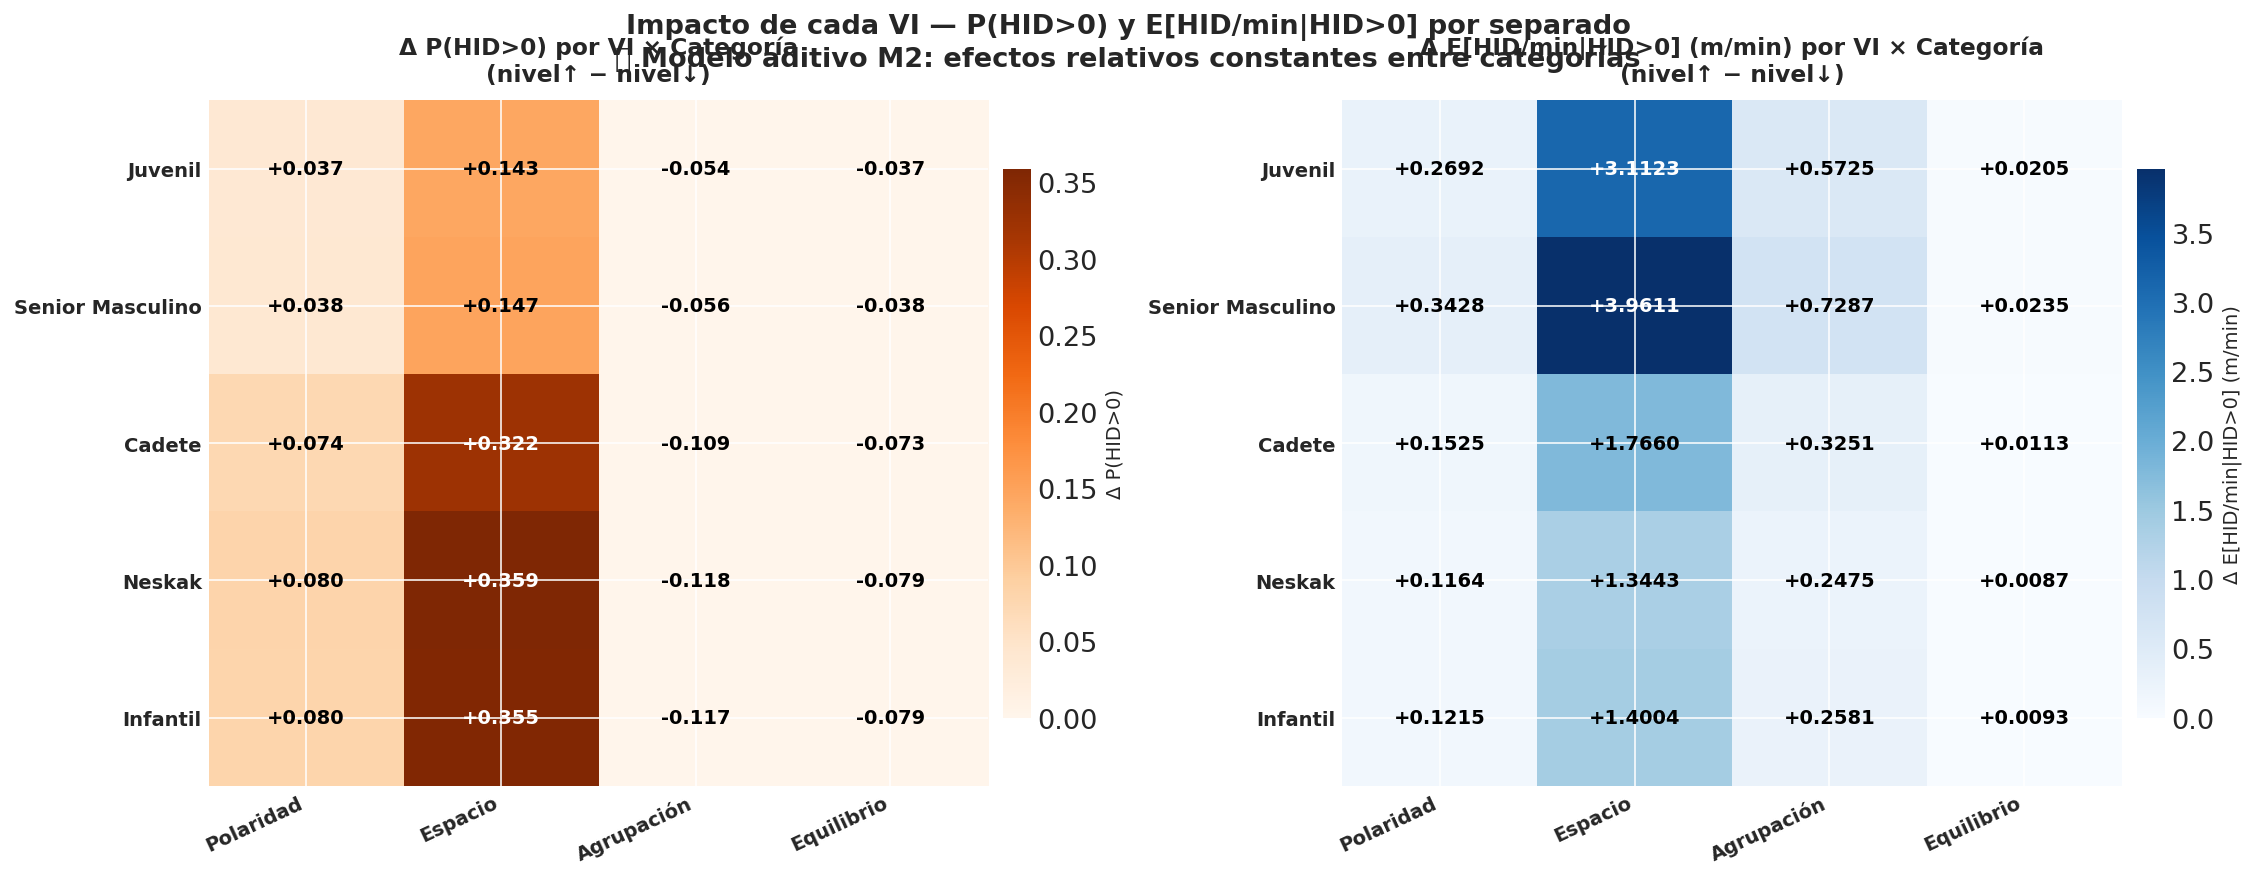

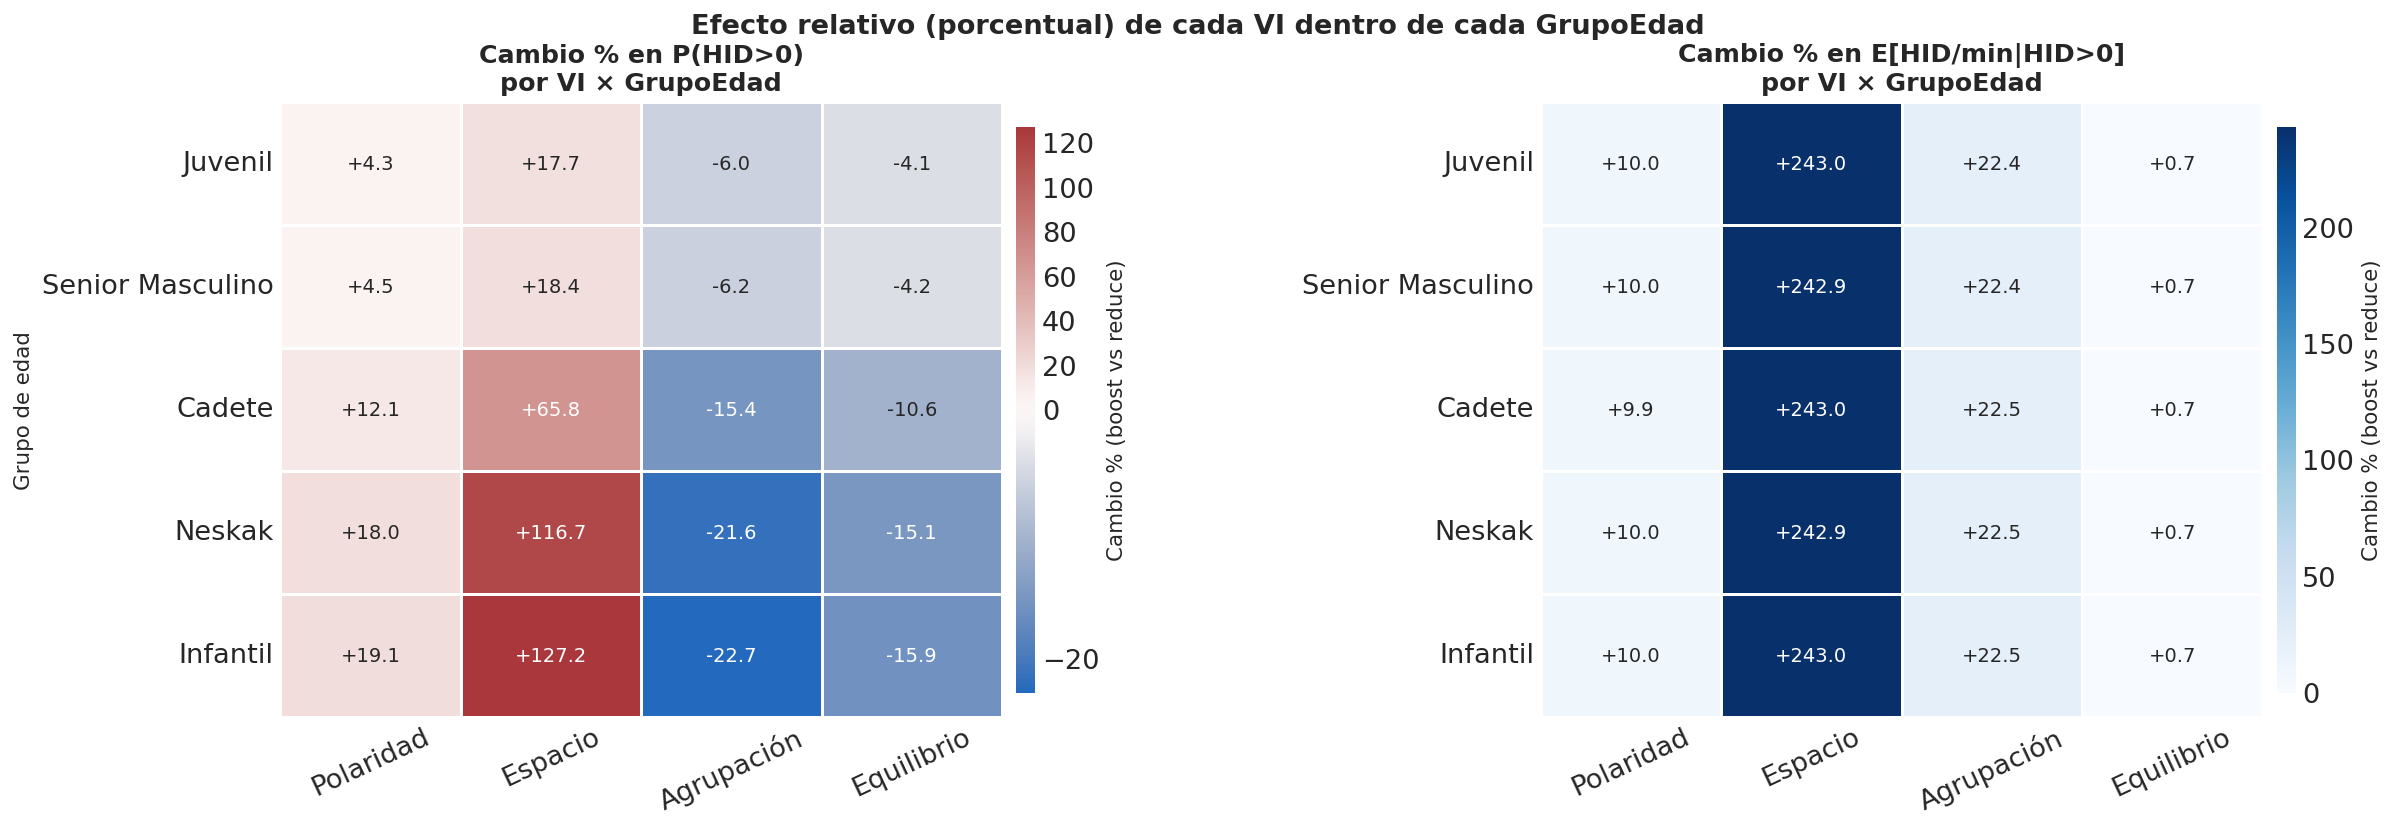

In [13]:
# ══════════════════════════════════════════════════════════════════════════
#  VERIFICACIÓN: TENDENCIAS Y CAMBIOS POR PARTE (ψ y μ por separado)
#  ✅ M2 aditivo → efectos relativos constantes entre categorías
# ══════════════════════════════════════════════════════════════════════════

n_cats = len(orden_categorias)

# ── 1. Tendencias: ¿boost > reduce en todas las categorías? ──────────────
print("═" * 100)
print("  1. TENDENCIAS: ¿El nivel 'boost' siempre supera al 'reduce'?")
print("═" * 100)

for metrica, etiq in [("psi", "P(HID>0)"), ("mu", "E[HID/min|HID>0]")]:
    print(f"\n  ── {etiq} ──")
    print(f"  {'VI':<14} {'Boost':>14} {'Reduce':>14}", end="")
    for cat in orden_categorias:
        print(f"  {'Dir':>10}", end="")
    print()
    print("  " + "─" * (14 + 14 + 14 + 12 * n_cats))

    for vi in orden_vi:
        nb, nr = nivel_boost[vi], nivel_reduce[vi]
        print(f"  {vi:<14} {nb:>14} {nr:>14}", end="")
        for cat in orden_categorias:
            emm_b = emm_vi_ge[cat][vi][nb][metrica][0]
            emm_r = emm_vi_ge[cat][vi][nr][metrica][0]
            if emm_b >= emm_r:
                print(f"  {'↑ Boost':>10}", end="")
            else:
                print(f"  {'↓ Reduce':>10}", end="")
        print()

# ── 2. Cambio % por parte separada ──────────────────────────────────────
for metrica, etiq, fmt in [("psi", "P(HID>0)", ".1f"), ("mu", "E[HID/min|HID>0]", ".1f")]:
    print(f"\n{'═' * 100}")
    print(f"  2. CAMBIO % EN {etiq} POR VI × GRUPO DE EDAD")
    print("     (✅ Constante en escala log/logit — M2 aditivo)")
    print(f"{'═' * 100}")
    print(f"\n  {'VI':<14}", end="")
    for cat in orden_categorias:
        print(f"  {cat:>16}", end="")
    print()
    print("  " + "─" * (14 + 18 * n_cats))

    for vi in orden_vi:
        nb, nr = nivel_boost[vi], nivel_reduce[vi]
        print(f"  {vi:<14}", end="")
        for cat in orden_categorias:
            emm_b = emm_vi_ge[cat][vi][nb][metrica][0]
            emm_r = emm_vi_ge[cat][vi][nr][metrica][0]
            pct = (emm_b / emm_r - 1) * 100 if emm_r > 0 else 0
            print(f"  {pct:>+14.1f} %", end="")
        print()

# ── 3. Tabla global con ambas partes ─────────────────────────────────────
print(f"\n{'═' * 100}")
print("  3. EMM GLOBAL POR CATEGORÍA: P(HID>0) y E[HID/min|HID>0]")
print(f"{'═' * 100}")
print(f"\n  {'Categoría':<20} {'P(HID>0)':>10} {'HDI 95%':>18} {'E[HID|>0]':>12} {'HDI 95%':>20}")
print("  " + "─" * 82)

for cat in orden_categorias:
    mp, lop, hip = emm_global[cat]["psi"]
    mm, lom, him = emm_global[cat]["mu"]
    print(f"  {cat:<20} {mp:>10.3f} [{lop:.3f}, {hip:.3f}]"
          f" {mm:>12.4f} [{lom:.4f}, {him:.4f}]")

# ── 4. Visualización: Δ por parte separada ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="white")

for ax_idx, (metrica, etiq, cmap_name, fmt) in enumerate([
    ("psi", "Δ P(HID>0)", "Oranges", "+.3f"),
    ("mu",  "Δ E[HID/min|HID>0] (m/min)", "Blues", "+.4f"),
]):
    ax = axes[ax_idx]
    mat = np.zeros((len(orden_categorias), len(orden_vi)))
    for i, cat in enumerate(orden_categorias):
        for j, vi in enumerate(orden_vi):
            b = emm_vi_ge[cat][vi][nivel_boost[vi]][metrica][0]
            r = emm_vi_ge[cat][vi][nivel_reduce[vi]][metrica][0]
            mat[i, j] = b - r

    im = ax.imshow(mat, cmap=cmap_name, aspect="auto", vmin=0)
    ax.set_xticks(range(len(orden_vi)))
    ax.set_xticklabels(orden_vi, fontsize=10, fontweight="bold", rotation=25, ha="right")
    ax.set_yticks(range(len(orden_categorias)))
    ax.set_yticklabels(orden_categorias, fontsize=10, fontweight="bold")
    ax.set_title(f"{etiq} por VI × Categoría\n(nivel↑ − nivel↓)",
                 fontsize=12, fontweight="bold", pad=10)
    for i in range(len(orden_categorias)):
        for j in range(len(orden_vi)):
            val = mat[i, j]
            txt_c = "white" if val > mat.max() * 0.6 else "black"
            ax.text(j, i, f"{val:{fmt}}", ha="center", va="center",
                    fontsize=10, fontweight="bold", color=txt_c)
    cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label(etiq, fontsize=10)

fig.suptitle("Impacto de cada VI — P(HID>0) y E[HID/min|HID>0] por separado\n"
             "✅ Modelo aditivo M2: efectos relativos constantes entre categorías",
             fontsize=14, fontweight="bold", y=1.02)
fig.subplots_adjust(top=0.88, wspace=0.30)
plt.show()

# ── 5. Visualización (recomendada): CAMBIO % por VI × GrupoEdad ──────────
#     (Mismo estilo que en Golpeos: 2 heatmaps + columna hueco y exportación.)
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path

def _matriz_cambio_pct(metrica: str) -> pd.DataFrame:
    """Matriz (GrupoEdad × VI) del cambio %: (boost/reduce - 1)·100."""
    mat = np.zeros((len(orden_categorias), len(orden_vi)))
    for i, cat in enumerate(orden_categorias):
        for j, vi in enumerate(orden_vi):
            b = emm_vi_ge[cat][vi][nivel_boost[vi]][metrica][0]
            r = emm_vi_ge[cat][vi][nivel_reduce[vi]][metrica][0]
            mat[i, j] = (b / r - 1) * 100 if r > 0 else np.nan
    return pd.DataFrame(mat, index=orden_categorias, columns=orden_vi)

df_pct_psi = _matriz_cambio_pct("psi")
df_pct_mu = _matriz_cambio_pct("mu")

# Nota: evitamos fig.tight_layout() porque puede fallar con colorbars (layout engine).
# Layout: 2 paneles + columna separadora para empujar el panel derecho un poco a la derecha.
fig = plt.figure(figsize=(17.0, 5.6), facecolor="white")
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 0.22, 1.0])
ax_left = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 2])

# ψ: divergente centrado en 0
psi_min = float(np.nanmin(df_pct_psi.values))
psi_max = float(np.nanmax(df_pct_psi.values))
psi_hm_kwargs = {}
if psi_min < 0 < psi_max:
    psi_hm_kwargs["norm"] = TwoSlopeNorm(vmin=psi_min, vcenter=0.0, vmax=psi_max)
else:
    psi_hm_kwargs["vmin"] = psi_min
    psi_hm_kwargs["vmax"] = psi_max

sns.heatmap(
    df_pct_psi, ax=ax_left, cmap="vlag",
    annot=True, fmt="+.1f", linewidths=0.6, linecolor="white",
    cbar_kws={"label": "Cambio % (boost vs reduce)", "shrink": 0.92, "pad": 0.02, "aspect": 30},
    **psi_hm_kwargs,
)
ax_left.set_title("Cambio % en P(HID>0)\npor VI × GrupoEdad", fontweight="bold")
ax_left.set_xlabel("")
ax_left.set_ylabel("Grupo de edad")
ax_left.set_aspect("auto")

# μ: secuencial y empezando SIEMPRE desde 0
mu_max = float(np.nanmax(df_pct_mu.values))
sns.heatmap(
    df_pct_mu, ax=ax_right, cmap="Blues",
    vmin=0.0, vmax=mu_max,
    annot=True, fmt="+.1f", linewidths=0.6, linecolor="white",
    cbar_kws={"label": "Cambio % (boost vs reduce)", "shrink": 0.92, "pad": 0.02, "aspect": 30},
)
ax_right.set_title("Cambio % en E[HID/min|HID>0]\npor VI × GrupoEdad", fontweight="bold")
ax_right.set_xlabel("")
ax_right.set_ylabel("")
ax_right.set_aspect("auto")

for ax in (ax_left, ax_right):
    ax.tick_params(axis="x", rotation=25)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Efecto relativo (porcentual) de cada VI dentro de cada GrupoEdad",
    fontsize=14, fontweight="bold", y=1.03,
)

# Ajuste manual (robusto con colorbars)
fig.subplots_adjust(left=0.07, right=0.98, bottom=0.16, top=0.74)

# Guardado (útil para la memoria / fichas)
output_dir = Path("imagenes_exportadas")
output_dir.mkdir(exist_ok=True)
fig.savefig(output_dir / "hid_cambio_pct_vi_x_grupoedad.png", bbox_inches="tight")

plt.show()

---
## 9 · Ranking de los 16 Escenarios y Comparaciones Clave

¿El ranking por P(HID > 0) se mantiene entre categorías? ¿Y el de E[HID/min | HID > 0]?

- **E[HID/min | HID > 0]**: El ranking es **idéntico** entre categorías (modelo aditivo → exp(β) constante).
- **P(HID > 0)**: El ranking **puede variar ligeramente** por la no-linealidad de la transformación logit→prob, aunque los OR son constantes.

**Escenarios extremos esperados para HID:**
- **Máximo**: Espacio=amplio + Agrupacion=pequeña (espacios amplios fuerzan carreras largas, grupos pequeños exigen mayor implicación individual)
- **Mínimo**: Espacio=reducido + Agrupacion=grande

La diferencia entre el escenario máximo y mínimo puede alcanzar un ~256% entre espacios.

════════════════════════════════════════════════════════════════════════════════
  1. COMPARACIÓN DEL RANKING DE LOS 16 ESCENARIOS (por P(HID>0))
════════════════════════════════════════════════════════════════════════════════

✅ El ranking por P(HID>0) es IDÉNTICO en las 5 categorías.

════════════════════════════════════════════════════════════════════════════════
  2. COMPARACIONES CLAVE ENTRE ESCENARIOS
════════════════════════════════════════════════════════════════════════════════

  🔴 #1 (máx) vs #16 (mín) — rango total:
    Juvenil               P(HID>0): 0.976 vs 0.697 (+40.0 %)  |  E[HID|>0]: 4.1197 vs 1.3463 (+206.0 %)
    Senior Masculino      P(HID>0): 0.975 vs 0.688 (+41.7 %)  |  E[HID|>0]: 5.2459 vs 1.7136 (+206.1 %)
    Cadete                P(HID>0): 0.898 vs 0.333 (+169.4 %)  |  E[HID|>0]: 2.3378 vs 0.7642 (+205.9 %)
    Neskak                P(HID>0): 0.798 vs 0.183 (+335.9 %)  |  E[HID|>0]: 1.7797 vs 0.5818 (+205.9 %)
    Infantil              P(HID>0): 0.773 vs 0.1

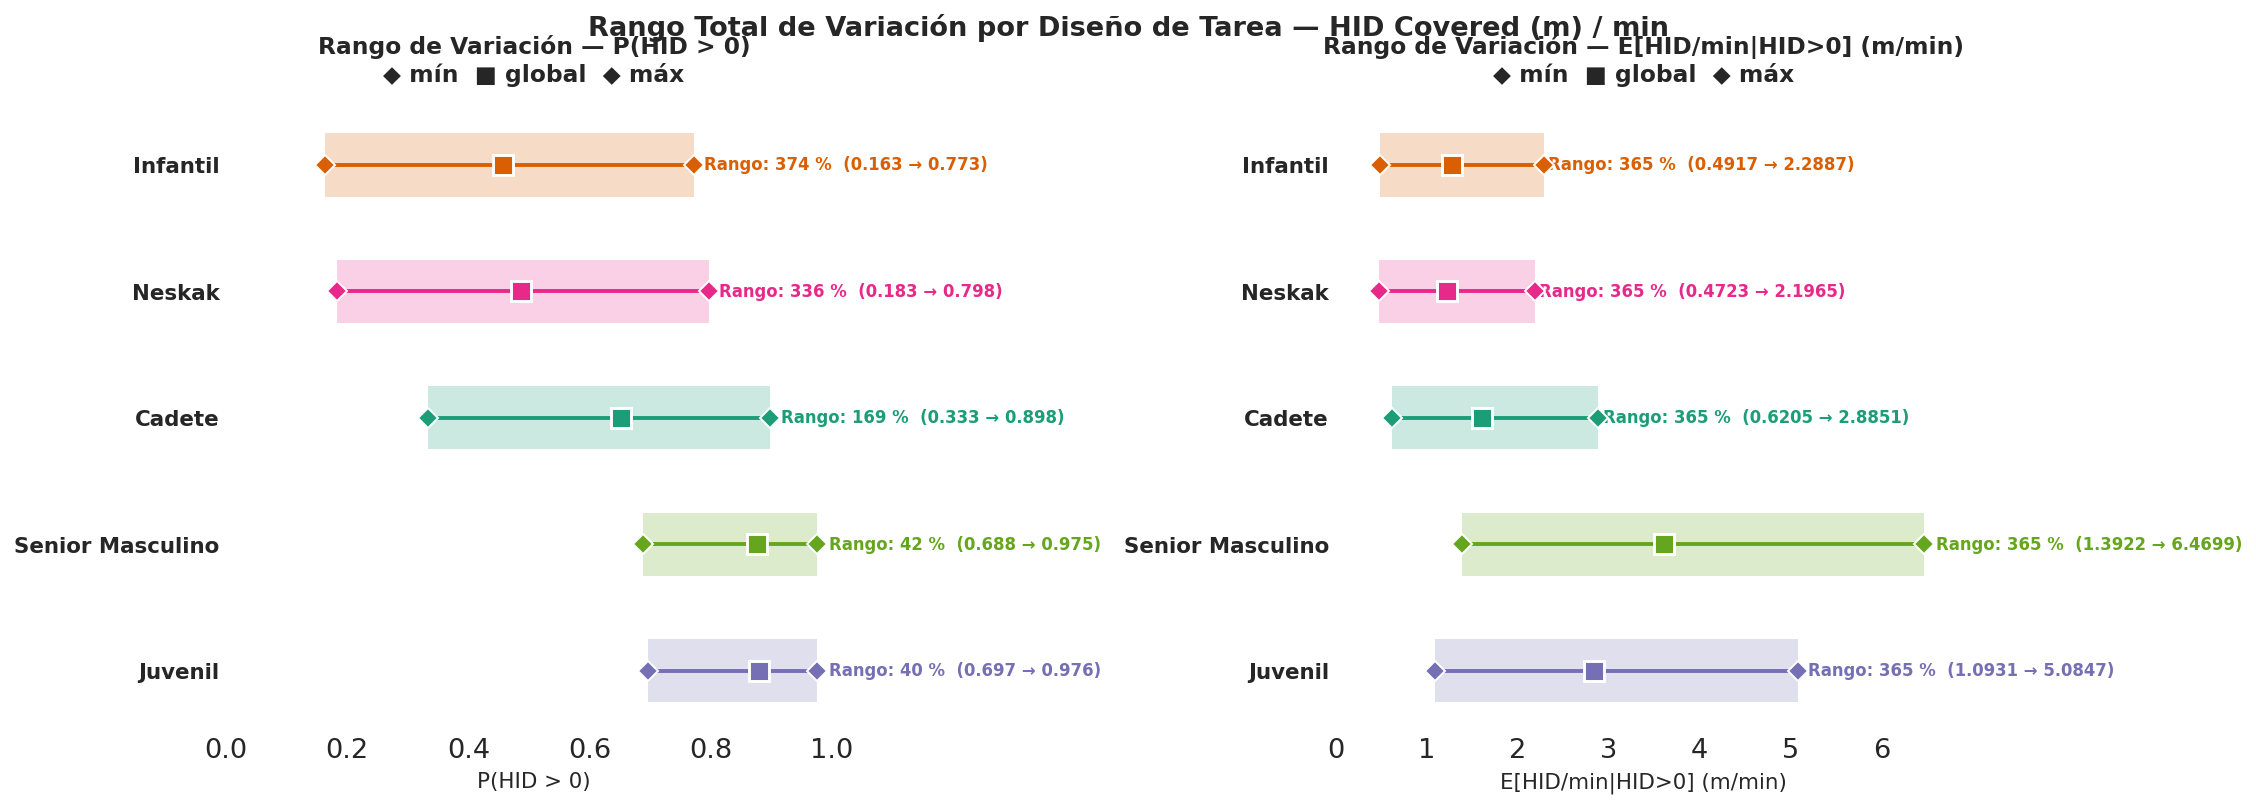

In [14]:
# ══════════════════════════════════════════════════════════════════════════
#  RANKING Y COMPARACIONES CLAVE — P(HID>0) y E[HID/min|HID>0]
# ══════════════════════════════════════════════════════════════════════════

# ── 1. ¿Ranking idéntico entre categorías? ───────────────────────────────
print("═" * 80)
print("  1. COMPARACIÓN DEL RANKING DE LOS 16 ESCENARIOS (por P(HID>0))")
print("═" * 80)

ref_cat = orden_categorias[0]
ref_labels = [e["label"] for e in todos_esc[ref_cat]]

orden_identico = True
for cat in orden_categorias[1:]:
    labels = [e["label"] for e in todos_esc[cat]]
    if labels != ref_labels:
        orden_identico = False
        print(f"\n⚠️  {cat} difiere de {ref_cat}:")
        for i, (r, c) in enumerate(zip(ref_labels, labels)):
            if r != c:
                print(f"    Pos {i+1}: {ref_cat} → {r}  vs  {cat} → {c}")

if orden_identico:
    print(f"\n✅ El ranking por P(HID>0) es IDÉNTICO en las {n_cats} categorías.")
else:
    print(f"\n⚠️ Hay diferencias en el ranking entre categorías (esperable por interacciones en M3).")

# ── 2. Comparaciones clave — en ambas métricas ──────────────────────────
print(f"\n{'═' * 80}")
print("  2. COMPARACIONES CLAVE ENTRE ESCENARIOS")
print(f"{'═' * 80}")

comparaciones = [
    ("🔴 #1 (máx) vs #16 (mín) — rango total", 0, 15),
    ("🟠 #1 vs #8 — mitad superior", 0, 7),
    ("🟡 #8 vs #16 — mitad inferior", 7, 15),
]

for desc, i1, i2 in comparaciones:
    print(f"\n  {desc}:")
    for cat in orden_categorias:
        e1 = todos_esc[cat][i1]
        e2 = todos_esc[cat][i2]
        pct_psi = (e1["psi"] / e2["psi"] - 1) * 100 if e2["psi"] > 0 else 0
        pct_mu  = (e1["mu"]  / e2["mu"]  - 1) * 100 if e2["mu"]  > 0 else 0
        print(f"    {cat:20s}  P(HID>0): {e1['psi']:.3f} vs {e2['psi']:.3f} ({pct_psi:+.1f} %)"
              f"  |  E[HID|>0]: {e1['mu']:.4f} vs {e2['mu']:.4f} ({pct_mu:+.1f} %)")

# ── 3. Promedio Top-4 vs Bottom-4 — ambas métricas ──────────────────────
print(f"\n{'═' * 80}")
print("  3. PROMEDIO TOP-4 vs BOTTOM-4 ESCENARIOS")
print(f"{'═' * 80}")
print(f"\n  {'Categoría':<20}", end="")
print(f" {'P(HID>0)':>8} {'Top-4':>8} {'Bot-4':>8} {'Δ':>8}", end="")
print(f"  {'E[HID|>0]':>9} {'Top-4':>9} {'Bot-4':>9} {'Δ':>9}")
print("  " + "─" * 92)

for cat in orden_categorias:
    esc = todos_esc[cat]
    gp = emm_global[cat]["psi"][0]
    gm = emm_global[cat]["mu"][0]
    top4_psi = np.mean([esc[i]["psi"] for i in range(4)])
    bot4_psi = np.mean([esc[i]["psi"] for i in range(12, 16)])
    top4_mu  = np.mean([esc[i]["mu"]  for i in range(4)])
    bot4_mu  = np.mean([esc[i]["mu"]  for i in range(12, 16)])
    print(f"  {cat:<20}", end="")
    print(f" {gp:>8.3f} {top4_psi:>8.3f} {bot4_psi:>8.3f} {top4_psi - bot4_psi:>+8.3f}", end="")
    print(f"  {gm:>9.4f} {top4_mu:>9.4f} {bot4_mu:>9.4f} {top4_mu - bot4_mu:>+9.4f}")

# ── 4. Visualización: rango por categoría — ambas métricas ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), facecolor="white")

for ax_idx, (metrica, etiq, fmt_val) in enumerate([
    ("psi", "P(HID > 0)", ".3f"),
    ("mu",  "E[HID/min|HID>0] (m/min)", ".4f"),
]):
    ax = axes[ax_idx]
    for i, cat in enumerate(orden_categorias):
        esc = todos_esc[cat]
        e_max = max(e[metrica] for e in esc)
        e_min = min(e[metrica] for e in esc)
        g = emm_global[cat][metrica][0]
        color = colores_cat[cat]
        pct_range = (e_max / e_min - 1) * 100 if e_min > 0 else 0

        ax.barh(i, e_max - e_min, left=e_min, height=0.5,
                color=color, alpha=0.22, edgecolor="none")
        ax.plot(g, i, "s", color=color, ms=10, mec="white", mew=1.5, zorder=5)
        ax.plot([e_min, e_max], [i, i], "-", color=color, lw=2)
        ax.plot(e_min, i, "D", color=color, ms=7, mec="white", mew=1, zorder=5)
        ax.plot(e_max, i, "D", color=color, ms=7, mec="white", mew=1, zorder=5)
        ax.text(e_max + (e_max * 0.02), i,
                f"Rango: {pct_range:.0f} %  ({e_min:{fmt_val}} → {e_max:{fmt_val}})",
                fontsize=8.5, fontweight="bold", color=color, va="center")

    ax.set_yticks(range(len(orden_categorias)))
    ax.set_yticklabels(orden_categorias, fontsize=11, fontweight="bold")
    ax.set_xlabel(etiq, fontsize=11)
    ax.set_title(f"Rango de Variación — {etiq}\n◆ mín  ■ global  ◆ máx",
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(axis="x", alpha=0.2, ls=":")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(left=0)

fig.suptitle("Rango Total de Variación por Diseño de Tarea — HID Covered (m) / min",
             fontsize=14, fontweight="bold", y=1.02)
fig.subplots_adjust(top=0.86, wspace=0.35)
plt.show()

---
## 📝 Nota Metodológica

### Enfoque: dos métricas separadas, no la combinada

Este notebook presenta las fichas descomponiendo las EMMs en sus **dos partes
constituyentes** del modelo Hurdle Gamma:

| Métrica | Significado | Enlace | Escala |
|---|---|---|---|
| **P(HID > 0)** | Probabilidad de carrera de alta intensidad | logit | 0–1 (probabilidad) |
| **E[HID/min \| HID > 0]** | Distancia a alta intensidad dado que ocurre sprint | log | m/min (positivos) |

Esta descomposición es más informativa que la combinada E[Y] = ψ × μ porque:

1. **Revela mecanismos**: ¿la tarea activa sprints (ψ) o concentra la distancia acumulada (μ)?
2. **Orienta la prescripción**: un entrenador que quiera asegurar que ocurran carreras de alta intensidad
   debe mirar P(HID>0); uno que quiera maximizar la distancia acumulada cuando ocurren, E[HID/min|HID>0].
3. **Evita confusión**: la media combinada puede ocultar que un diseño aumenta
   la probabilidad pero reduce la distancia (o viceversa).

### Modelo

M2 — Hurdle Gamma con 5 efectos principales (Espacio, Agrupación, Polaridad,
Equilibrio, GrupoEdad) y efectos aleatorios por jugador en ambas partes.
Seleccionado por LOO-CV como mejor modelo predictivo (peso stacking = 0.915,
elpd_diff = 0 respecto a M3).

**Parte mu (Gamma, log-link) — Intensidad condicional E[HID/min | HID > 0]:**

$$
\log(\mu_{ij}) \;=\; \alpha_\mu + \beta_{\mu,\text{Esp}} + \beta_{\mu,\text{Agr}} +
\beta_{\mu,\text{Pol}} + \beta_{\mu,\text{Eq}} + \beta_{\mu,\text{GE}} +
u_{\mu,j}, \quad u_{\mu,j} \sim \mathcal{N}(0, \sigma_{\mu,u}^2)
$$

**Parte psi (logit-link) — Probabilidad de sprint P(HID > 0):**

$$
\text{logit}(\psi_{ij}) \;=\; \alpha_\psi + \gamma_{\psi,\text{Esp}} + \gamma_{\psi,\text{Agr}} +
\gamma_{\psi,\text{Pol}} + \gamma_{\psi,\text{Eq}} + \gamma_{\psi,\text{GE}} +
u_{\psi,j}, \quad u_{\psi,j} \sim \mathcal{N}(0, \sigma_{\psi,u}^2)
$$

- **Familia**: Hurdle Gamma (logit + Gamma/log).
- **Efectos aleatorios**: intercepto por jugador (`1|PlayerId`) en ambas partes.
- **Posterior**: 8 000 muestras (4 cadenas × 2 000 iteraciones).
- **HDI 95 %**: Intervalo de Densidad más Alta de la posterior.

### Interpretación para entrenadores

Un entrenador que quiera asegurar que ocurran carreras de alta intensidad
debe mirar P(HID > 0); uno que quiera maximizar la distancia acumulada cuando
ocurren, E[HID/min | HID > 0].

La diferencia clave respecto a otras VD: **el espacio es el factor dominante**,
con una diferencia del ~256% entre espacios amplio y reducido.

| VI | Efecto sobre P(HID>0) | Efecto sobre E[HID/min\|HID>0] | Rol |
|---|---|---|---|
| **Espacio** | ↑↑↑ (dominante) | ↑↑↑ (dominante) | Factor principal para HID |
| **Polaridad** | ↑ | ~ | Activa sprints |
| **Agrupación** | ~ | ↑ | Modula intensidad |
| **Equilibrio** | n.s. | n.s. | Sin efecto creíble |

### Invariancia entre categorías

**Para HID/min con M2, los efectos relativos SON constantes** entre categorías de edad.
Las fichas individuales muestran perfiles cualitativamente idénticos;
las diferencias absolutas reflejan únicamente el nivel base de cada grupo.

| Métrica | Ratio entre niveles | Δ absoluto |
|---|---|---|
| **E[HID/min \| HID > 0]** | ✅ Constante (exp(β) compartido) | Varía con nivel base |
| **P(HID > 0)** | ✅ OR constante | Cuasi-constante (logit no lineal) |